In [6]:
from collections import Counter

import torch

import altair as alt
from scipy.stats import pearsonr

import os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from natsort import natsorted
import logomaker

from netam import framework
from dnsmex import dxsm_data, dnsm_zoo
from dnsmex.dnsm_oe import write_sites_oe
from dnsmex.local import localify


from netam.common import heavy_chain_shim
from netam.framework import load_crepe, load_pcp_df
from netam.sequences import translate_sequence, AA_STR_SORTED

from dnsmex.dasm_viz import dms_style_heatmap
from dnsmex.local import localify
from dnsmex.dxsm_data import pcp_df_of_nickname

figures_dir = localify("FIGURES_DIR")

## Prep data - Rodriguez dataset

In [7]:
%%bash
## get counts of V and J genes
zcat /fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v1/rodriguez-airr-seq-race-prod-InclMutInv_pcp_2024-11-12_MASKED_NI_noN_no-naive_addJ.csv.gz | tail -n +2 | cut -d ',' -f 11 | cut -d '-' -f 1 | sort | uniq -c | sort -nr
echo "---"
zcat /fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v1/rodriguez-airr-seq-race-prod-InclMutInv_pcp_2024-11-12_MASKED_NI_noN_no-naive_addJ.csv.gz | tail -n +2 | cut -d ',' -f 20 | cut -d '*' -f 1 | sort | uniq -c | sort -nr

   9985 IGHV3
   5246 IGHV4
   4328 IGHV1
    944 IGHV5
    771 IGHV2
    351 IGHV6
    129 IGHV7
---
  11562 IGHJ4
   3563 IGHJ6
   2863 IGHJ5
   2825 IGHJ3
    562 IGHJ2
    379 IGHJ1


In [8]:
dataset_name = "v1rodriguez"
model_name = "dnsm_1m-v1jaffe+v1tang-joint"

crepe_prefix = localify(f"DNSM_TRAINED_MODELS_DIR/{model_name}")
test_output_prefix = localify(f"DNSM_TEST_OUTPUT_DIR/{model_name}-ON-{dataset_name}")

try:
    site_sub_probs_df = pd.read_csv(f"{test_output_prefix}-site_sub_probs_df.csv")
    pcp_df = pd.read_csv(f"{test_output_prefix}-pcp_df.csv")


except FileNotFoundError:
    if not os.path.exists(f"{test_output_prefix}.branch_lengths_csv"):
        dnsm_zoo.write_branch_lengths("/fh/fast/matsen_e/shared/bcr-mut-sel/dnsm/dnsm-experiments-1/dnsm-train/trained_models/dnsm_1m-v1jaffe+v1tang-joint", dataset_name, f"{test_output_prefix}.branch_lengths_csv")


    complete_plotter, plotter_dict = write_sites_oe(
        crepe_prefix=crepe_prefix,
        dataset_name=dataset_name,
        branch_length_path=f"{test_output_prefix}.branch_lengths_csv",
        csv_output_path=f"{test_output_prefix}-sites-oe.csv",
        fig_out_path=f"{figures_dir}/sites-oe-V1,3,4.svg",
        min_log_prob=-4,
        #v_families=["IGHV1", "IGHV2", "IGHV3", "IGHV4", "IGHV5", "IGHV6", "IGHV7"],
        replace_title=True,
    )
    complete_plotter = complete_plotter["heavy"]


    pcp_df = complete_plotter.pcp_df.copy()
    site_sub_probs_df = complete_plotter.site_sub_probs_df.copy()
    for column_name in ['selection_factor', 'neutral_prob', 'prob']:
        site_sub_probs_df[column_name] = site_sub_probs_df[column_name].apply(lambda x: x.item() if hasattr(x, 'item') else x)


    pcp_df.to_csv(f"{test_output_prefix}-pcp_df.csv", index=False)
    site_sub_probs_df.to_csv(f"{test_output_prefix}-site_sub_probs_df.csv", index=False)



    def site_sub_probs_df_without_low_freq(in_plotter, quantile_cutoff=0.05):
        site_sub_probs_df = in_plotter.site_sub_probs_df.copy()
        site_counts = site_sub_probs_df["site"].value_counts()
        cutoff = site_counts.quantile(quantile_cutoff)
        sites_above_cutoff = set(site_counts[site_counts > cutoff].index)
        site_sub_probs_df = site_sub_probs_df[site_sub_probs_df["site"].isin(sites_above_cutoff)]
        return site_sub_probs_df

    def sort_df_by_site(df):
        sorted_index = natsorted(df.index, key=lambda x: df.loc[x, 'site'])
        return df.iloc[sorted_index]

    def build_persite_df(site_sub_probs_df):
        persite_df = site_sub_probs_df.groupby(['site', 'is_cdr']).agg(
            mean_prob=('prob', 'mean'),
            mean_neutral_prob=('neutral_prob', 'mean'),
            mean_selection_factor=('selection_factor', 'mean'),
            mut_freq=('mutation', 'mean')
        ).reset_index()

        persite_df = sort_df_by_site(persite_df)

        return persite_df



In [ ]:
# add family annotations to aa and site substitution dfs
pcp_df['j_family'] = pcp_df['j_gene'].str.split('*').str[0]
pcp_df_for_merge = pcp_df.copy()
pcp_df_for_merge = pcp_df_for_merge[['v_gene', 'j_gene', 'v_family', 'j_family', 'sample_id', 'family', 'depth']]
pcp_df_for_merge['pcp_index'] = pcp_df_for_merge.index

site_sub_probs_df = pd.merge(site_sub_probs_df, pcp_df_for_merge, on='pcp_index', how='inner')

# add log scale
site_sub_probs_df['log_selection_factor'] = np.log(site_sub_probs_df['selection_factor'])


<Axes: xlabel='site', ylabel='Count'>

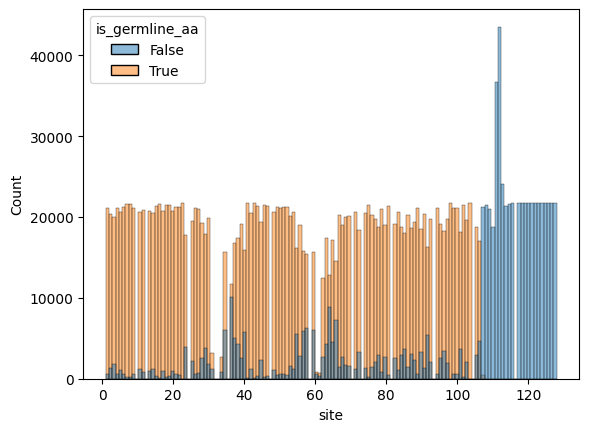

In [10]:
## add germline information
germline_codons_df = pd.read_csv(localify(f"DATA_DIR/germline_codons.csv"))
codon_similarity = pd.read_csv(localify(f"DATA_DIR/germline_codon_similarity.csv"))
aa_similarity = pd.read_csv(localify(f"DATA_DIR/germline_aa_similarity.csv"))
aa_similarity.set_index('v_gene', inplace=True)
codon_similarity.set_index('v_gene', inplace=True)





germline_codons_df['site'] = germline_codons_df['site'].astype(float)

site_sub_probs_df = pd.merge(site_sub_probs_df, germline_codons_df.rename(columns={'codon':'germline_codon', 'amino_acid':'germline_amino_acid'}).drop(columns=['v_family']), on=['v_gene', 'site'], how='left')

site_sub_probs_df['is_germline_aa'] = site_sub_probs_df.parent_aa == site_sub_probs_df.germline_amino_acid
site_sub_probs_df['is_germline_codon'] = site_sub_probs_df.parent_codon == site_sub_probs_df.germline_codon
sns.histplot(site_sub_probs_df, x='site', hue='is_germline_aa')

## Analysis

In [7]:
site_sub_probs_df

,neutral_prob,selection_factor,prob,mutation,pcp_index,site,is_cdr,parent_codon,parent_aa,child_codon,...,j_gene,v_family,j_family,sample_id,family,log_selection_factor,germline_codon,germline_amino_acid,is_germline_aa,is_germline_codon
0,0.102066,0.132334,0.013507,False,0,1.0,False,CAG,Q,CAG,...,IGHJ4*02,IGHV7,IGHJ4,sample-igg-SC-24,1401,-2.022430,CAG,Q,True,True
1,0.030019,0.132334,0.003972,False,1,1.0,False,CAG,Q,CAG,...,IGHJ4*02,IGHV7,IGHJ4,sample-igg-SC-24,1401,-2.022430,CAG,Q,True,True
2,0.011072,0.229902,0.002546,False,2,1.0,False,CAG,Q,CAG,...,IGHJ4*02,IGHV4,IGHJ4,sample-igg-SC-24,474,-1.470103,CAG,Q,True,True
3,0.054606,0.262477,0.014333,False,3,1.0,False,CAG,Q,CAG,...,IGHJ6*02,IGHV4,IGHJ6,sample-igg-SC-24,238,-1.337593,CAG,Q,True,True
4,0.010781,0.262477,0.002830,False,4,1.0,False,CAG,Q,CAG,...,IGHJ6*02,IGHV4,IGHJ6,sample-igg-SC-24,238,-1.337593,CAG,Q,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2646366,0.001440,1.122413,0.001617,False,21747,128.0,False,TCA,S,TCA,...,IGHJ1*01,IGHV1,IGHJ1,sample-igg-W-109,62,0.115481,NaN,NaN,False,False
2646367,0.001785,1.077277,0.001923,False,21748,128.0,False,TCA,S,TCA,...,IGHJ5*02,IGHV3,IGHJ5,sample-igg-W-109,10,0.074437,NaN,NaN,False,False
2646368,0.001744,1.077277,0.001879,False,21749,128.0,False,TCA,S,TCA,...,IGHJ5*02,IGHV3,IGHJ5,sample-igg-W-109,10,0.074437,NaN,NaN,False,False
2646369,0.001797,1.249783,0.002246,False,21750,128.0,False,TCA,S,TCA,...,IGHJ4*02,IGHV1,IGHJ4,sample-igg-W-117,10,0.222970,NaN,NaN,False,False


In [7]:
## validate analysis with DNSM plot - makes sense

temp_df = site_sub_probs_df[site_sub_probs_df.v_family.isin(['IGHV3', 'IGHV4'])]
temp_df = temp_df.groupby(['v_family', 'site']).selection_factor.mean().reset_index().pivot(index='site', columns='v_family', values='selection_factor')
temp_df['mean_selection_diff'] = temp_df['IGHV3'] - temp_df['IGHV4']
temp_df

v_family,IGHV3,IGHV4,mean_selection_diff
site,,,
1.0,0.767281,0.194199,0.573082
2.0,0.677434,0.621131,0.056303
3.0,0.556742,0.483011,0.073731
4.0,0.252657,0.131288,0.121369
5.0,0.469319,0.449225,0.020094
...,...,...,...
124.0,0.143972,0.210664,-0.066692
125.0,0.557629,0.579749,-0.022120
126.0,0.076136,0.103745,-0.027609


<Axes: xlabel='site', ylabel='selection_factor'>

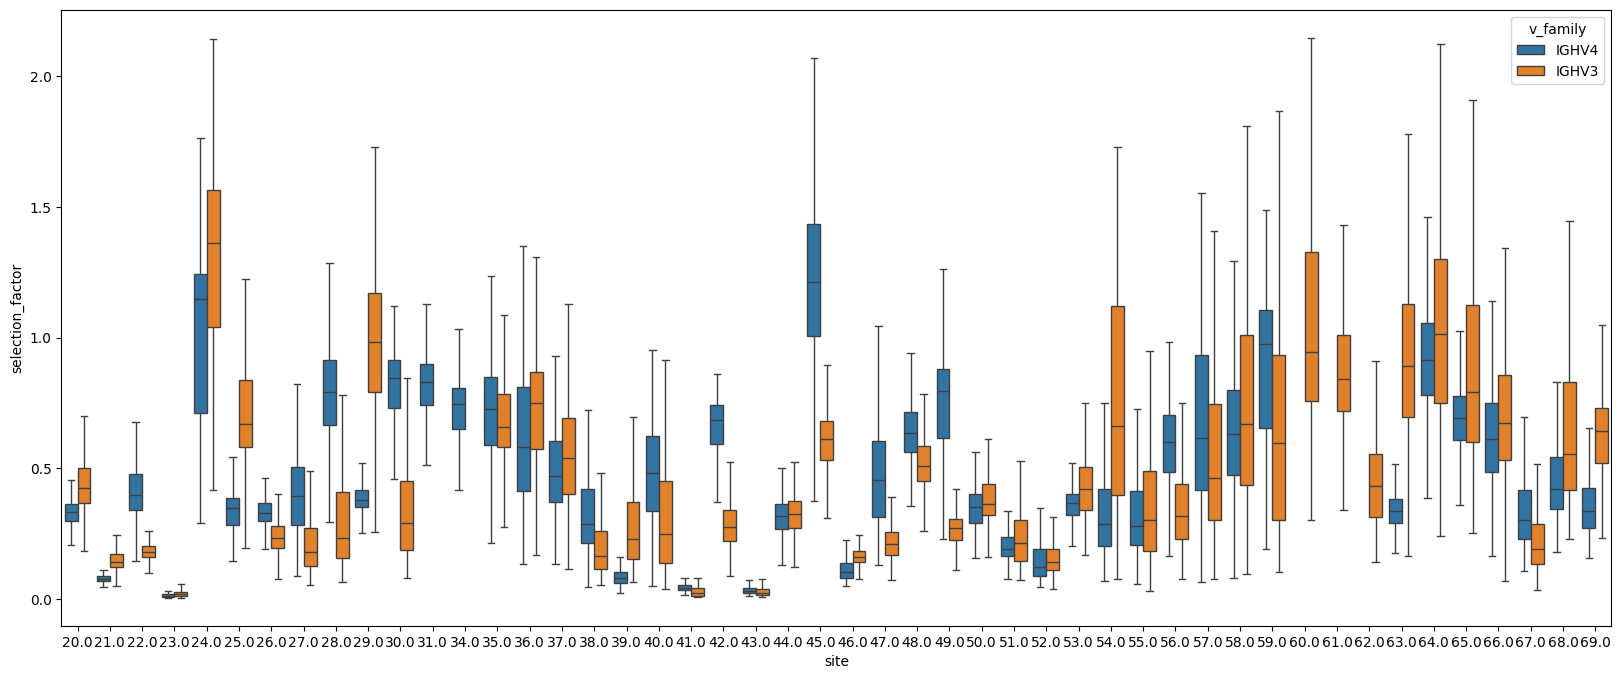

In [8]:
fig, ax = plt.subplots(figsize=(20, 8))
sns.boxplot(data=site_sub_probs_df[(site_sub_probs_df.site.isin([float(i) for i in list(range(20,70))])) & (site_sub_probs_df.v_family.isin(['IGHV3', 'IGHV4']))], x='site', y='selection_factor', hue='v_family', showfliers=False, ax=ax)



## compare V and J gene families selection factors

In [18]:
#### per site difference between v3 and v4 usign seqeunces
## simplify DNSM paper and look at two genes


site_sub_probs_df[site_sub_probs_df.v_family.isin(['IGHV3', 'IGHV4'])].groupby('v_gene').size().sort_values(ascending=False).head(20)

our_common_vgenes = ['IGHV3-23*01', 
                     'IGHV4-39*01']

#if wanting to compare within v family:
our_common_v3_genes = ['IGHV3-23*01', 
                     'IGHV3-74*01']

In [ ]:
def compare_v_genes_barplot(v_gene1, v_gene2, site_sub_probs_df_germline, figsize=(13, 5), limit_pcp_depth=True):
    df = site_sub_probs_df_germline[site_sub_probs_df_germline.v_gene.isin([v_gene1, v_gene2])].copy()
    df = df[df['is_germline_codon'] == True]

    if limit_pcp_depth:
        # Limit to only pcps that are 2 levels away from the naive, which are likely the most reliable
        df = df[df.depth == 2]

    median_log_selection_factors_1 = df[(df.v_gene == v_gene1)].groupby(['site', 'parent_aa', 'is_cdr']).log_selection_factor.median().reset_index().copy()
    median_log_selection_factors_2 = df[(df.v_gene == v_gene2)].groupby(['site', 'parent_aa', 'is_cdr']).log_selection_factor.median().reset_index().copy()
    median_log_selection_factors_compare = pd.merge(median_log_selection_factors_1, median_log_selection_factors_2, on=['site', 'is_cdr'], how='inner', suffixes=('_1', '_2'))
    
    # Calculate difference (v_gene1 - v_gene2)
    median_log_selection_factors_compare['difference'] = (median_log_selection_factors_compare['log_selection_factor_1'] - 
                                                         median_log_selection_factors_compare['log_selection_factor_2'])
    
    # Sort by difference for better visualization
    #median_log_selection_factors_compare = median_log_selection_factors_compare.sort_values('difference').reset_index(drop=True)
    
    # Add color column to dataframe based on whether parent amino acids are different
    median_log_selection_factors_compare['germline_aa_status'] = median_log_selection_factors_compare.apply(
        lambda row: 'Different germline AA' if row['parent_aa_1'] != row['parent_aa_2'] else 'Same germline AA', axis=1
    )

    # Create the plot using seaborn
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create barplot with seaborn
    sns.barplot(data=median_log_selection_factors_compare, 
                x='site', y='difference', 
                hue='germline_aa_status',
                palette={'Same germline AA': 'blue', 'Different germline AA': 'red'},
                alpha=0.7, ax=ax, dodge=False)
    
    # After creating the barplot, create a mapping of site to CDR status
    site_to_cdr = dict(zip(median_log_selection_factors_compare['site'], 
                        median_log_selection_factors_compare['is_cdr']))

    # Color CDR sites labels in red and bold
    for i, tick_label in enumerate(ax.get_xticklabels()):
        site = float(tick_label.get_text())  # Convert tick label text to site number
        if site_to_cdr.get(site, False):
            tick_label.set_color('red')
            tick_label.set_fontweight('bold')
    
    # Customize the plot
    ax.set_xlabel('Site', fontsize=12)
    ax.set_ylabel(f'Log Selection Factor Difference\n({v_gene1} - {v_gene2})', fontsize=12)
    ax.set_title(f'Selection Factor Differences: {v_gene1} vs {v_gene2}', fontsize=14)
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.5)  # Reference line at 0
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=90)
    
    # Create custom legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='blue', alpha=0.7, label='Same germline AA'),
        Patch(facecolor='red', alpha=0.7, label='Different germline AA')
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    return median_log_selection_factors_compare, fig, ax




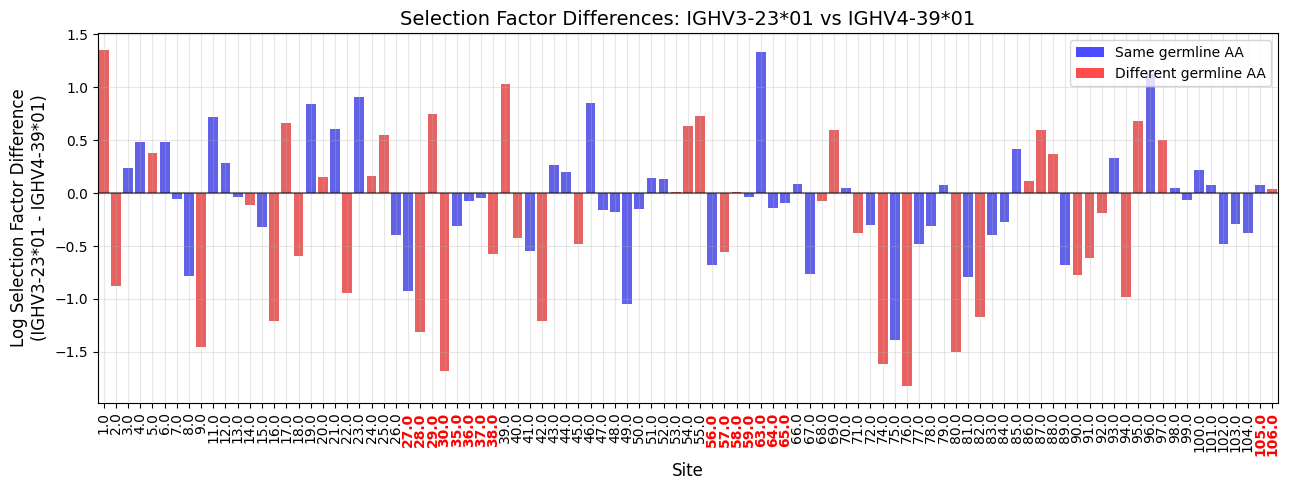

,site,parent_aa_1,is_cdr,log_selection_factor_1,parent_aa_2,log_selection_factor_2,difference,germline_aa_status
0,1.0,E,False,-0.526592,Q,-1.877196,1.350603,Different germline AA
1,2.0,V,False,-0.766236,L,0.114151,-0.880388,Different germline AA
2,3.0,Q,False,-0.619345,Q,-0.855403,0.236058,Same germline AA
3,4.0,L,False,-1.403600,L,-1.888247,0.484647,Same germline AA
4,5.0,L,False,-0.471332,Q,-0.852149,0.380818,Different germline AA
...,...,...,...,...,...,...,...,...
92,102.0,Y,False,-3.211268,Y,-2.731105,-0.480163,Same germline AA
93,103.0,Y,False,-0.994125,Y,-0.706075,-0.288050,Same germline AA
94,104.0,C,False,-2.816464,C,-2.441535,-0.374930,Same germline AA
95,105.0,A,True,-0.374930,A,-0.449364,0.074434,Same germline AA


In [66]:
median_log_selection_factors_compare, fig, ax = compare_v_genes_barplot('IGHV3-23*01', 'IGHV4-39*01', site_sub_probs_df_germline)
median_log_selection_factors_compare

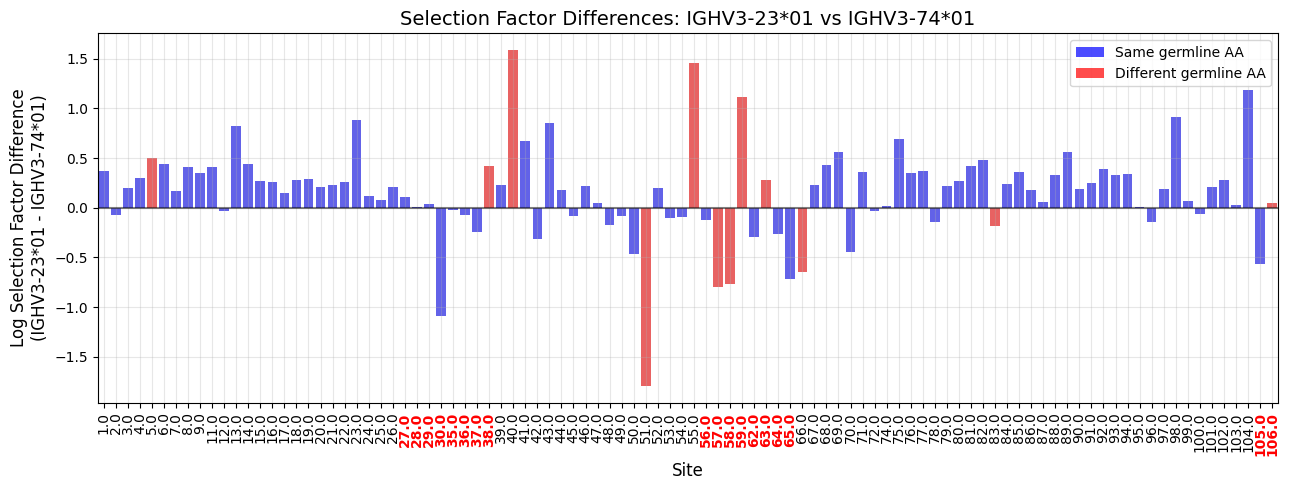

In [ ]:
### THIS PLOT SHOWS THAT COMPARING ONLY TWO GENES MIGHT BE MISLEADING, AS23*01 HAS MORE SELECTION THAT 74*01 ACROSS MOST SITES, WHICH LOOKS LIKE AN ARTIFACT.

median_log_selection_factors_compare, fig, ax = compare_v_genes_barplot('IGHV3-23*01', 'IGHV3-74*01', site_sub_probs_df_germline)

In [ ]:
def filter_sites_by_vfamily_coverage(df, min_pct=0.1):
    filtered_df = pd.DataFrame()
    for v_family in df['v_family'].unique():
        v_family_df = df[df['v_family'] == v_family]
        
        for site in v_family_df['site'].unique():
            site_df = v_family_df[v_family_df['site'] == site]
            total_site_samples = site_df['pcp_index'].nunique()
            
            for amino_acid in site_df['parent_aa'].unique():
                aa_samples = site_df[site_df['parent_aa'] == amino_acid]['pcp_index'].nunique()
                if aa_samples / total_site_samples >= min_pct:
                    filtered_df = pd.concat([filtered_df, site_df[site_df['parent_aa'] == amino_acid]])
    
    return filtered_df

def compare_v_families_barplot(v_family1, v_family2, site_sub_probs_df_germline, figsize=(13, 5), limit_pcp_depth=True):
    df = site_sub_probs_df_germline[site_sub_probs_df_germline.v_family.isin([v_family1, v_family2])].copy()
    df = df[df['is_germline_codon'] == True]

    if limit_pcp_depth:
        # Limit to only pcps that are 2 levels away from the naive, which are likely the most reliable
        df = df[df.depth == 2]

    # filter sites that appear at less than 5% per v family
    df = filter_sites_by_vfamily_coverage(df, min_pct=0.1)

    median_log_selection_factors_1 = df[(df.v_family == v_family1)].groupby(['site', 'parent_aa', 'is_cdr']).log_selection_factor.median().reset_index().copy()
    median_log_selection_factors_2 = df[(df.v_family == v_family2)].groupby(['site', 'parent_aa', 'is_cdr']).log_selection_factor.median().reset_index().copy()
    median_log_selection_factors_compare = pd.merge(median_log_selection_factors_1, median_log_selection_factors_2, on=['site', 'is_cdr'], how='inner', suffixes=('_1', '_2'))
    
    # Calculate difference (v_gene1 - v_gene2)
    median_log_selection_factors_compare['difference'] = (median_log_selection_factors_compare['log_selection_factor_1'] - 
                                                         median_log_selection_factors_compare['log_selection_factor_2'])
    
    
    # Add color column to dataframe based on whether parent amino acids are different
    median_log_selection_factors_compare['germline_aa_status'] = median_log_selection_factors_compare.apply(
        lambda row: 'Different germline AA' if row['parent_aa_1'] != row['parent_aa_2'] else 'Same germline AA', axis=1
    )

    # Create the plot using seaborn
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create barplot with seaborn
    sns.scatterplot(data=median_log_selection_factors_compare, 
                x='site', y='difference', 
                hue='germline_aa_status',
                palette={'Same germline AA': 'blue', 'Different germline AA': 'red'},
                alpha=0.7, ax=ax)
    
    # Add colored background regions for CDR-like regions
    cdr_regions = [(27, 38), (56, 65), (105, 117)]

    for (start_site, end_site) in cdr_regions:
        ax.axvspan(start_site, end_site, alpha=0.1, color='red', zorder=0)
    
    
    # Customize the plot
    ax.set_xlabel('Site', fontsize=12)
    ax.set_ylabel(f'Log Selection Factor Difference\n({v_family1} - {v_family2})', fontsize=12)
    ax.set_title(f'Selection Factor Differences: {v_family1} vs {v_family2}', fontsize=14)
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.5)  # Reference line at 0
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(0, int(median_log_selection_factors_compare['site'].max()) + 1, 5))
    plt.xticks(rotation=90)
    
    # Create custom legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='blue', alpha=0.7, label='Same germline AA'),
        Patch(facecolor='red', alpha=0.7, label='Different germline AA')
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    
    plt.tight_layout()
    plt.show()
    
    return median_log_selection_factors_compare, fig, ax




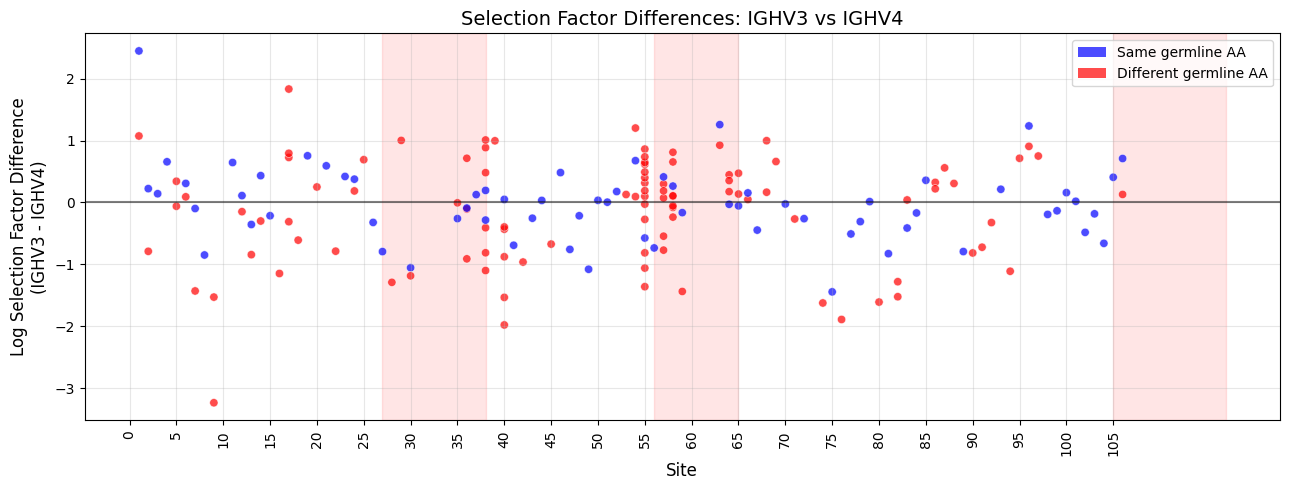

(      site parent_aa_1  is_cdr  log_selection_factor_1 parent_aa_2  \
 0      1.0           E   False               -0.705852           Q   
 1      1.0           Q   False                0.668675           Q   
 2      2.0           V   False               -0.665727           L   
 3      2.0           V   False               -0.665727           V   
 4      3.0           Q   False               -0.661207           Q   
 ..     ...         ...     ...                     ...         ...   
 164  103.0           Y   False               -1.013516           Y   
 165  104.0           C   False               -3.081521           C   
 166  105.0           A    True               -0.224091           A   
 167  106.0           K    True               -1.059149           R   
 168  106.0           R    True               -0.478765           R   
 
      log_selection_factor_2  difference     germline_aa_status  
 0                 -1.779291    1.073439  Different germline AA  
 1            

In [105]:
compare_v_families_barplot('IGHV3', 'IGHV4', site_sub_probs_df)

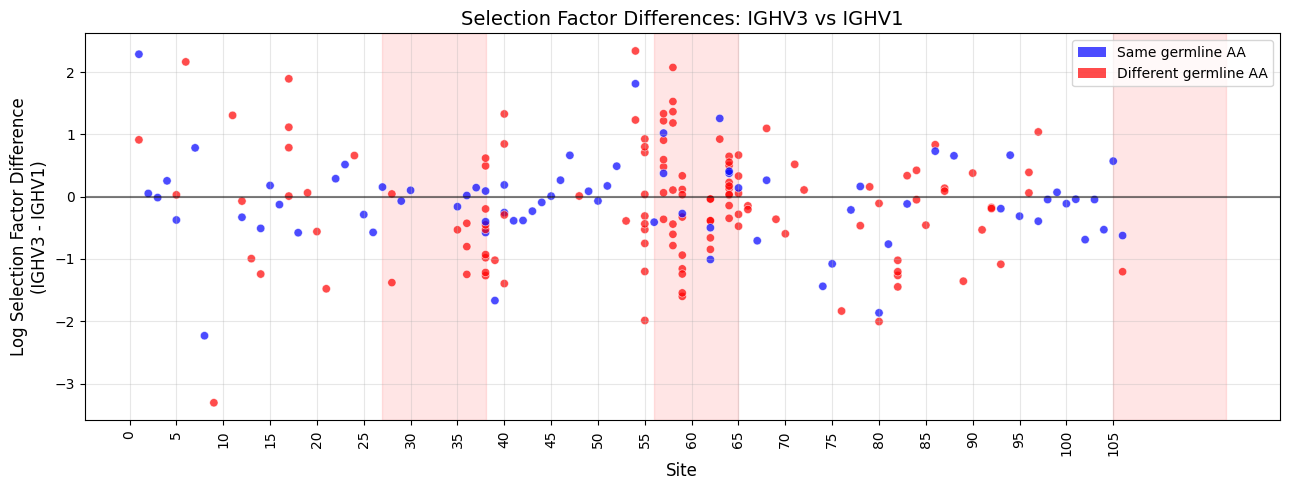

(      site parent_aa_1  is_cdr  log_selection_factor_1 parent_aa_2  \
 0      1.0           E   False               -0.705852           Q   
 1      1.0           Q   False                0.668675           Q   
 2      2.0           V   False               -0.665727           V   
 3      3.0           Q   False               -0.661207           Q   
 4      4.0           L   False               -1.499879           L   
 ..     ...         ...     ...                     ...         ...   
 198  103.0           Y   False               -1.013516           Y   
 199  104.0           C   False               -3.081521           C   
 200  105.0           A    True               -0.224091           A   
 201  106.0           K    True               -1.059149           R   
 202  106.0           R    True               -0.478765           R   
 
      log_selection_factor_2  difference     germline_aa_status  
 0                 -1.618454    0.912602  Different germline AA  
 1            

In [106]:
compare_v_families_barplot('IGHV3', 'IGHV1', site_sub_probs_df)

/tmp/ipykernel_2422494/589023285.py:197: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


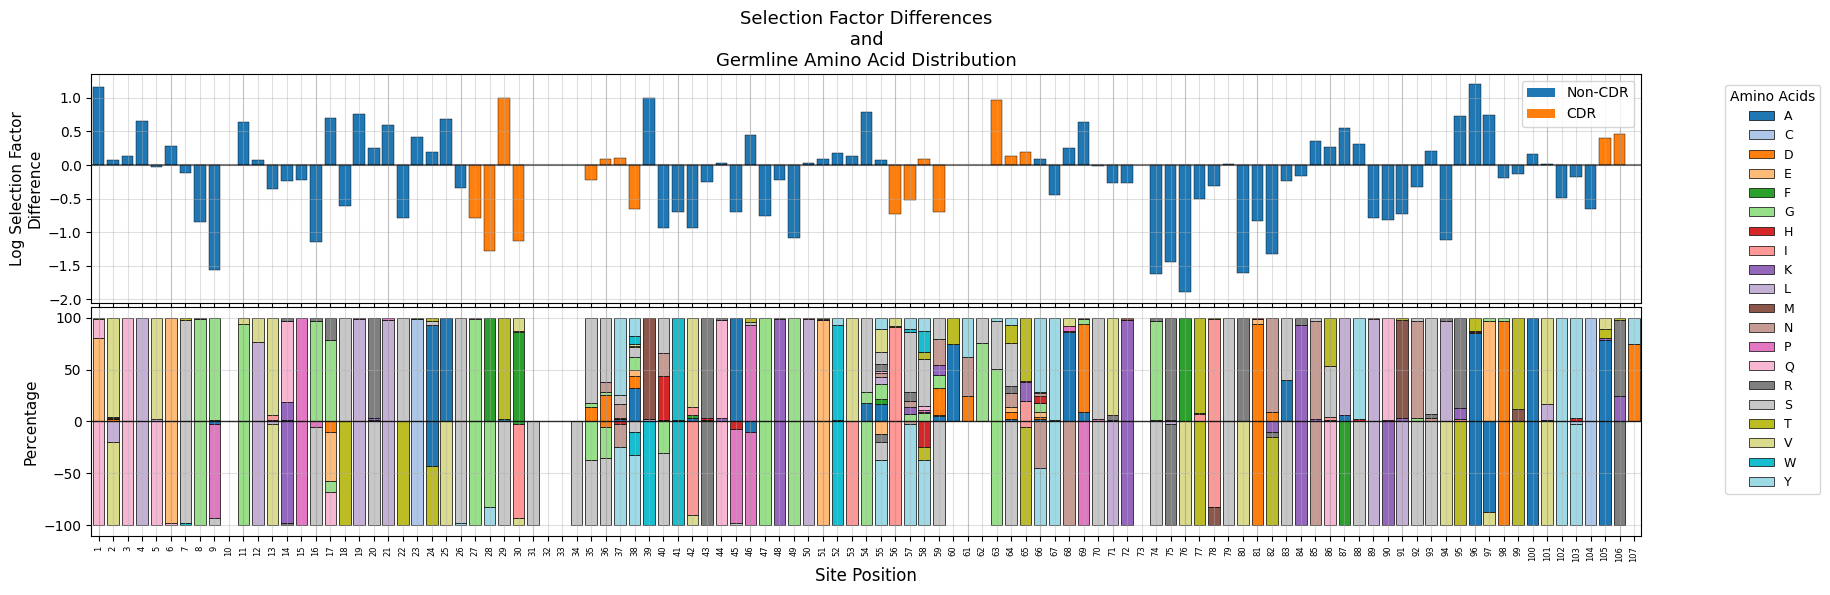

In [17]:
def combined_vfamily_plots(v_family1, v_family2, germline_codons_df, site_sub_probs_df_germline, figsize=(20, 6)):
    """
    Create combined plots:
    - Top: Selection factor differences (scatter plot)
    - Bottom: Mirrored amino acid distribution 
    Both plots share the same x-axis
    """
    
    # Create subplots with shared x-axis
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, 
                                   gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.02})
    
    # ===== TOP PLOT: SELECTION FACTOR DIFFERENCES =====
    
    # Prepare selection factor data
    df = site_sub_probs_df_germline[site_sub_probs_df_germline.v_family.isin([v_family1, v_family2])].copy()
    df = df[df['is_germline_codon'] == True]

    median_log_selection_factors_1 = df[(df.v_family == v_family1)].groupby(['site', 'is_cdr']).log_selection_factor.median().reset_index().copy()
    median_log_selection_factors_2 = df[(df.v_family == v_family2)].groupby(['site', 'is_cdr']).log_selection_factor.median().reset_index().copy()
    median_log_selection_factors_compare = pd.merge(median_log_selection_factors_1, median_log_selection_factors_2, on=['site', 'is_cdr'], how='inner', suffixes=('_1', '_2'))
    
    # Calculate difference
    median_log_selection_factors_compare['difference'] = (median_log_selection_factors_compare['log_selection_factor_1'] - 
                                                         median_log_selection_factors_compare['log_selection_factor_2'])
    
    # Create bar plot using matplotlib with actual site positions for proper alignment
    # Create colors based on CDR status (using seaborn default colors)
    colors = ['#ff7f0e' if is_cdr else '#1f77b4' for is_cdr in median_log_selection_factors_compare['is_cdr']]
    
    # Plot bars at actual site positions
    ax1.bar(median_log_selection_factors_compare['site'], 
            median_log_selection_factors_compare['difference'], 
            color=colors, width=0.8, edgecolor='black', linewidth=0.3)
    
    # Create legend for CDR status
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#1f77b4', label='Non-CDR'),
        Patch(facecolor='#ff7f0e', label='CDR')
    ]
    ax1.legend(handles=legend_elements, loc='upper right')
    
    # Customize top plot
    ax1.set_ylabel(f'Log Selection Factor\nDifference', fontsize=11)
    ax1.set_title(f'Selection Factor Differences\n and \nGermline Amino Acid Distribution', fontsize=13)
    ax1.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    ax1.grid(True, alpha=0.4, linewidth=0.8)
    
    # ===== BOTTOM PLOT: MIRRORED AMINO ACID DISTRIBUTION =====
    
    # Filter data for each family
    family1_data = germline_codons_df[germline_codons_df.v_family == v_family1].copy()
    family2_data = germline_codons_df[germline_codons_df.v_family == v_family2].copy()
    
    # Get common site range - handle NaN values
    min_site = min(family1_data.site.min(), family2_data.site.min())
    max_site = max(family1_data.site.max(), family2_data.site.max())
    
    # Check for NaN values and handle them
    if pd.isna(min_site) or pd.isna(max_site):
        print("Warning: No data found for one or both V families")
        return None, None, None
    
    # Convert to integers for range function
    min_site = int(min_site)
    max_site = int(max_site)
    bins = range(min_site, max_site + 2)
    
    # Get all unique amino acids from both families
    all_amino_acids = sorted(set(family1_data['amino_acid'].unique()) | 
                           set(family2_data['amino_acid'].unique()))
    
    # Use tab20 colormap
    colors = plt.cm.tab20(np.linspace(0, 1, len(all_amino_acids)))
    color_map = dict(zip(all_amino_acids, colors))
    
    # Calculate percentages for family1 (above x-axis)
    family1_counts = {}
    family1_totals = np.zeros(len(bins)-1, dtype=float)
    
    for aa in all_amino_acids:
        aa_data = family1_data[family1_data['amino_acid'] == aa]
        if len(aa_data) > 0:
            hist, bin_edges = np.histogram(aa_data['site'], bins=bins)
            family1_counts[aa] = hist.astype(float)
        else:
            family1_counts[aa] = np.zeros(len(bins)-1, dtype=float)
        family1_totals += family1_counts[aa]
    
    # Convert to percentages
    for aa in all_amino_acids:
        family1_counts[aa] = np.divide(family1_counts[aa], family1_totals, 
                                     out=np.zeros_like(family1_counts[aa], dtype=float), 
                                     where=family1_totals!=0) * 100
    
    # Calculate percentages for family2 (below x-axis)
    family2_counts = {}
    family2_totals = np.zeros(len(bins)-1, dtype=float)
    
    for aa in all_amino_acids:
        aa_data = family2_data[family2_data['amino_acid'] == aa]
        if len(aa_data) > 0:
            hist, bin_edges = np.histogram(aa_data['site'], bins=bins)
            family2_counts[aa] = hist.astype(float)
        else:
            family2_counts[aa] = np.zeros(len(bins)-1, dtype=float)
        family2_totals += family2_counts[aa]
    
    # Convert to percentages and make negative
    for aa in all_amino_acids:
        family2_counts[aa] = -np.divide(family2_counts[aa], family2_totals, 
                                      out=np.zeros_like(family2_counts[aa], dtype=float), 
                                      where=family2_totals!=0) * 100
    
    # Plot both families with consistent styling - use actual site positions like top plot
    # Get all sites that have data in either family
    all_sites_with_data = sorted(set(family1_data['site'].unique()) | set(family2_data['site'].unique()))
    
    # Calculate percentages for family1 at specific sites
    family1_site_counts = {}
    for aa in all_amino_acids:
        aa_data = family1_data[family1_data['amino_acid'] == aa]
        site_counts = aa_data['site'].value_counts()
        family1_site_counts[aa] = site_counts
    
    # Calculate percentages for family2 at specific sites  
    family2_site_counts = {}
    for aa in all_amino_acids:
        aa_data = family2_data[family2_data['amino_acid'] == aa]
        site_counts = aa_data['site'].value_counts()
        family2_site_counts[aa] = site_counts
    
    # Plot family1 above x-axis (positive values) - stack them
    for site in all_sites_with_data:
        bottom1 = 0
        site_total = sum([family1_site_counts[aa].get(site, 0) for aa in all_amino_acids])
        
        for aa in all_amino_acids:
            count = family1_site_counts[aa].get(site, 0)
            if count > 0 and site_total > 0:
                percentage = (count / site_total) * 100
                ax2.bar(site, percentage, bottom=bottom1, 
                       color=color_map[aa], width=0.8, 
                       edgecolor='black', linewidth=0.5, align='center')
                bottom1 += percentage
    
    # Plot family2 below x-axis (negative values) - stack them
    for site in all_sites_with_data:
        bottom2 = 0
        site_total = sum([family2_site_counts[aa].get(site, 0) for aa in all_amino_acids])
        
        for aa in all_amino_acids:
            count = family2_site_counts[aa].get(site, 0)
            if count > 0 and site_total > 0:
                percentage = -(count / site_total) * 100  # Negative for below x-axis
                ax2.bar(site, percentage, bottom=bottom2, 
                       color=color_map[aa], width=0.8, 
                       edgecolor='black', linewidth=0.5, align='center')
                bottom2 += percentage
    
    # Customize bottom plot
    ax2.set_ylabel(f'Percentage', fontsize=11)
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.8, linewidth=1)
    ax2.grid(True, alpha=0.4, linewidth=0.8)
    
    # Create legend for amino acids
    legend_handles = []
    legend_labels = []
    for aa in all_amino_acids:
        legend_handles.append(plt.Rectangle((0,0),1,1, facecolor=color_map[aa], 
                                          edgecolor='black', linewidth=0.5))
        legend_labels.append(aa)
    
    ax2.legend(legend_handles, legend_labels, bbox_to_anchor=(1.05, 2), loc='upper left', 
              title='Amino Acids', fontsize=9)
    
    # Set x-axis limits and ticks to match between plots
    ax1.set_xlim(min_site - 0.5, max_site + 0.5)
    ax2.set_xlim(min_site - 0.5, max_site + 0.5)
    
    # Set x-axis ticks for every site with small font
    all_sites = range(min_site, max_site + 1)
    ax1.set_xticks(all_sites)
    ax2.set_xticks(all_sites)
    
    # Add vertical grid lines at every 5th site for easier comparison
    for site in range(min_site, max_site + 1, 5):
        ax1.axvline(x=site, color='gray', linestyle='-', alpha=0.3, linewidth=0.8)
        ax2.axvline(x=site, color='gray', linestyle='-', alpha=0.3, linewidth=0.8)
    
    # Only show x-tick labels on bottom plot with small font
    ax1.set_xticklabels([])
    ax2.set_xlabel('Site Position', fontsize=12)
    ax2.set_xticklabels(all_sites, rotation=90, fontsize=6)
    
    plt.tight_layout()
    plt.show()
    
    return median_log_selection_factors_compare, fig, (ax1, ax2)

# Usage:
result_df, fig, (ax1, ax2) = combined_vfamily_plots('IGHV3', 'IGHV4', germline_codons_df, site_sub_probs_df)

/tmp/ipykernel_2422494/3352996435.py:157: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


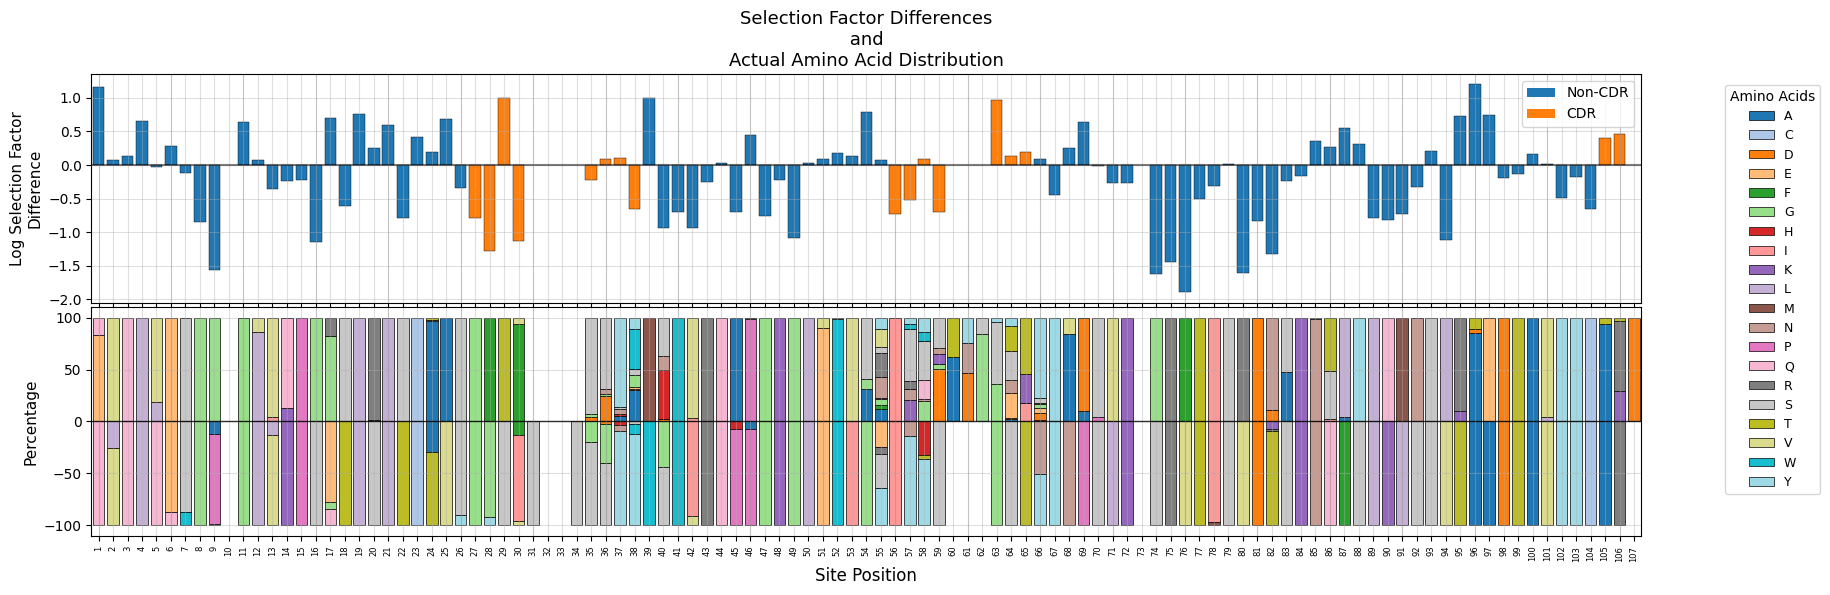

In [19]:
def combined_vfamily_plots_actual_aa(v_family1, v_family2, site_sub_probs_df_germline, figsize=(20, 6)):
    """
    Create combined plots:
    - Top: Selection factor differences (bar plot)
    - Bottom: Mirrored amino acid distribution from actual data (parent_aa column)
    Both plots share the same x-axis
    """
    
    # Create subplots with shared x-axis
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, 
                                   gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.02})
    
    # ===== TOP PLOT: SELECTION FACTOR DIFFERENCES =====
    
    # Prepare selection factor data
    df = site_sub_probs_df_germline[site_sub_probs_df_germline.v_family.isin([v_family1, v_family2])].copy()
    df = df[df['is_germline_codon'] == True]
    
    median_log_selection_factors_1 = df[(df.v_family == v_family1)].groupby(['site', 'is_cdr']).log_selection_factor.median().reset_index().copy()
    median_log_selection_factors_2 = df[(df.v_family == v_family2)].groupby(['site', 'is_cdr']).log_selection_factor.median().reset_index().copy()
    median_log_selection_factors_compare = pd.merge(median_log_selection_factors_1, median_log_selection_factors_2, on=['site', 'is_cdr'], how='inner', suffixes=('_1', '_2'))
    
    # Calculate difference
    median_log_selection_factors_compare['difference'] = (median_log_selection_factors_compare['log_selection_factor_1'] - 
                                                         median_log_selection_factors_compare['log_selection_factor_2'])
    
    # Create bar plot using matplotlib with actual site positions for proper alignment
    # Create colors based on CDR status (using seaborn default colors)
    colors = ['#ff7f0e' if is_cdr else '#1f77b4' for is_cdr in median_log_selection_factors_compare['is_cdr']]
    
    # Plot bars at actual site positions
    ax1.bar(median_log_selection_factors_compare['site'], 
            median_log_selection_factors_compare['difference'], 
            color=colors, width=0.8, edgecolor='black', linewidth=0.3)
    
    # Create legend for CDR status
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#1f77b4', label='Non-CDR'),
        Patch(facecolor='#ff7f0e', label='CDR')
    ]
    ax1.legend(handles=legend_elements, loc='upper right')
    
    # Customize top plot
    ax1.set_ylabel(f'Log Selection Factor\nDifference', fontsize=11)
    ax1.set_title(f'Selection Factor Differences\n and \nActual Amino Acid Distribution', fontsize=13)
    ax1.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    ax1.grid(True, alpha=0.4, linewidth=0.8)
    
    # ===== BOTTOM PLOT: MIRRORED AMINO ACID DISTRIBUTION FROM ACTUAL DATA =====
    
    # Filter data for each family from site_sub_probs_df
    family1_data = df[df.v_family == v_family1].copy()
    family2_data = df[df.v_family == v_family2].copy()
    
    # Get common site range - handle NaN values
    min_site = min(family1_data.site.min(), family2_data.site.min())
    max_site = max(family1_data.site.max(), family2_data.site.max())
    
    # Check for NaN values and handle them
    if pd.isna(min_site) or pd.isna(max_site):
        print("Warning: No data found for one or both V families")
        return None, None, None
    
    # Convert to integers
    min_site = int(min_site)
    max_site = int(max_site)
    
    # Get all unique amino acids from both families (from parent_aa column)
    all_amino_acids = sorted(set(family1_data['parent_aa'].unique()) | 
                           set(family2_data['parent_aa'].unique()))
    
    # Use tab20 colormap
    colors = plt.cm.tab20(np.linspace(0, 1, len(all_amino_acids)))
    color_map = dict(zip(all_amino_acids, colors))
    
    # Get all sites that have data in either family
    all_sites_with_data = sorted(set(family1_data['site'].unique()) | set(family2_data['site'].unique()))
    
    # Calculate percentages for family1 at specific sites
    family1_site_counts = {}
    for aa in all_amino_acids:
        aa_data = family1_data[family1_data['parent_aa'] == aa]
        site_counts = aa_data['site'].value_counts()
        family1_site_counts[aa] = site_counts
    
    # Calculate percentages for family2 at specific sites  
    family2_site_counts = {}
    for aa in all_amino_acids:
        aa_data = family2_data[family2_data['parent_aa'] == aa]
        site_counts = aa_data['site'].value_counts()
        family2_site_counts[aa] = site_counts
    
    # Plot family1 above x-axis (positive values) - stack them
    for site in all_sites_with_data:
        bottom1 = 0
        site_total = sum([family1_site_counts[aa].get(site, 0) for aa in all_amino_acids])
        
        for aa in all_amino_acids:
            count = family1_site_counts[aa].get(site, 0)
            if count > 0 and site_total > 0:
                percentage = (count / site_total) * 100
                ax2.bar(site, percentage, bottom=bottom1, 
                       color=color_map[aa], width=0.8, 
                       edgecolor='black', linewidth=0.5, align='center')
                bottom1 += percentage
    
    # Plot family2 below x-axis (negative values) - stack them
    for site in all_sites_with_data:
        bottom2 = 0
        site_total = sum([family2_site_counts[aa].get(site, 0) for aa in all_amino_acids])
        
        for aa in all_amino_acids:
            count = family2_site_counts[aa].get(site, 0)
            if count > 0 and site_total > 0:
                percentage = -(count / site_total) * 100  # Negative for below x-axis
                ax2.bar(site, percentage, bottom=bottom2, 
                       color=color_map[aa], width=0.8, 
                       edgecolor='black', linewidth=0.5, align='center')
                bottom2 += percentage
    
    # Customize bottom plot
    ax2.set_ylabel(f'Percentage', fontsize=11)
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.8, linewidth=1)
    ax2.grid(True, alpha=0.4, linewidth=0.8)
    
    # Create legend for amino acids
    legend_handles = []
    legend_labels = []
    for aa in all_amino_acids:
        legend_handles.append(plt.Rectangle((0,0),1,1, facecolor=color_map[aa], 
                                          edgecolor='black', linewidth=0.5))
        legend_labels.append(aa)
    
    ax2.legend(legend_handles, legend_labels, bbox_to_anchor=(1.05, 2), loc='upper left', 
              title='Amino Acids', fontsize=9)
    
    # Set x-axis limits and ticks to match between plots
    ax1.set_xlim(min_site - 0.5, max_site + 0.5)
    ax2.set_xlim(min_site - 0.5, max_site + 0.5)
    
    # Set x-axis ticks for every site with small font
    all_sites = range(min_site, max_site + 1)
    ax1.set_xticks(all_sites)
    ax2.set_xticks(all_sites)
    
    # Add vertical grid lines at every 5th site for easier comparison
    for site in range(min_site, max_site + 1, 5):
        ax1.axvline(x=site, color='gray', linestyle='-', alpha=0.3, linewidth=0.8)
        ax2.axvline(x=site, color='gray', linestyle='-', alpha=0.3, linewidth=0.8)
    
    # Only show x-tick labels on bottom plot with small font
    ax1.set_xticklabels([])
    ax2.set_xlabel('Site Position', fontsize=12)
    ax2.set_xticklabels(all_sites, rotation=90, fontsize=6)
    
    plt.tight_layout()
    plt.show()
    
    return median_log_selection_factors_compare, fig, (ax1, ax2)

# Usage:
result_df, fig, (ax1, ax2) = combined_vfamily_plots_actual_aa('IGHV3', 'IGHV4', site_sub_probs_df)

In [9]:
### tools for comparing two groups (can be full v families or just two v genes)

def compare_v_families(aa_site_subs_selection_df_germline, v_family1, v_family2, vcolumn='v_family', is_germline=True, codons_or_aa='codons', lower_log_selection_factor_lim=-4, create_randomized=False):
    '''
    vcolumn: column to use for v family comparison, e.g. 'v_family' or 'v_gene'
    '''
    if codons_or_aa == 'codons':
        if is_germline:
            aa_site_subs_selection_df_germline = aa_site_subs_selection_df_germline[aa_site_subs_selection_df_germline.is_germline_codon == True]
        median_log_selection_factors_1 = aa_site_subs_selection_df_germline[(aa_site_subs_selection_df_germline[vcolumn] == v_family1)].groupby(['site', 'parent_aa', 'parent_codon']).log_selection_factor.median().reset_index().copy()
        median_log_selection_factors_2 = aa_site_subs_selection_df_germline[(aa_site_subs_selection_df_germline[vcolumn] == v_family2)].groupby(['site', 'parent_aa', 'parent_codon']).log_selection_factor.median().reset_index().copy()
        median_log_selection_factors_compare = pd.merge(median_log_selection_factors_1, median_log_selection_factors_2, on=['site', 'parent_aa', 'parent_codon'], how='inner', suffixes=('_1', '_2'))
    elif codons_or_aa == 'aa':
        if is_germline:
            aa_site_subs_selection_df_germline = aa_site_subs_selection_df_germline[aa_site_subs_selection_df_germline.is_germline_aa == True]
        median_log_selection_factors_1 = aa_site_subs_selection_df_germline[(aa_site_subs_selection_df_germline[vcolumn] == v_family1)].groupby(['site', 'parent_aa']).log_selection_factor.median().reset_index().copy()
        median_log_selection_factors_2 = aa_site_subs_selection_df_germline[(aa_site_subs_selection_df_germline[vcolumn] == v_family2)].groupby(['site', 'parent_aa']).log_selection_factor.median().reset_index().copy()
        median_log_selection_factors_compare = pd.merge(median_log_selection_factors_1, median_log_selection_factors_2, on=['site', 'parent_aa'], how='inner', suffixes=('_1', '_2'))
    
    plot_dnsm_regression(median_log_selection_factors_compare, lower_log_selection_factor_lim=lower_log_selection_factor_lim, create_randomized=create_randomized, v_family1=v_family1, v_family2=v_family2)
    plot_site_comparison(median_log_selection_factors_compare, lower_log_selection_factor_lim=-4)
    
    return median_log_selection_factors_compare

def plot_dnsm_regression(median_log_selection_factors_compare, v_family1='v_family1', v_family2='v_family2', lower_log_selection_factor_lim=-4, create_randomized=False):
    # Drop NaN values for comparison
    clean_df = median_log_selection_factors_compare.dropna(subset=['log_selection_factor_1', 'log_selection_factor_2'])

    # Trim values below lower_log_selection_factor_lim
    clean_df_trimmed = clean_df.copy()
    clean_df_trimmed['log_selection_factor_1'] = clean_df_trimmed['log_selection_factor_1'].clip(lower=lower_log_selection_factor_lim)
    clean_df_trimmed['log_selection_factor_2'] = clean_df_trimmed['log_selection_factor_2'].clip(lower=lower_log_selection_factor_lim)

    # Calculate R-squared for original data
    r_original, p_original = pearsonr(clean_df_trimmed['log_selection_factor_1'], 
                                    clean_df_trimmed['log_selection_factor_2'])
    r_squared_original = r_original**2

    # Plot for the original coupled data (with trimmed values)
    plt.figure(figsize=(7, 5))
    g1 = sns.jointplot(data=clean_df_trimmed, x='log_selection_factor_1', y='log_selection_factor_2', 
                kind='hex', height=8, gridsize=75,
                marginal_kws=dict(bins=50, fill=True))
    # add x=y line
    xlim = g1.ax_joint.get_xlim()
    ylim = g1.ax_joint.get_ylim()
    lims = [max(xlim[0], ylim[0]), min(xlim[1], ylim[1])]
    g1.ax_joint.plot(lims, lims, 'r--', alpha=0.8, linewidth=2, label='x=y')

    g1.fig.suptitle(f'{v_family1} vs {v_family2} Comparison of Log Selection Factors for Germline encoded codons\nR² = {r_squared_original:.3f}', y=1.02)
    
    plt.tight_layout()
    plt.show()

    if create_randomized:
        # Create randomized version
        np.random.seed(42)
        randomized_df = clean_df_trimmed.copy()
        randomized_df['log_selection_factor_2'] = clean_df_trimmed['log_selection_factor_2'].sample(frac=1).values

        # Calculate R-squared for randomized data
        r_random, p_random = pearsonr(randomized_df['log_selection_factor_1'], 
                                    randomized_df['log_selection_factor_2'])
        r_squared_random = r_random**2

        # Plot for the randomized coupled data
        plt.figure(figsize=(7, 5))
        g2 = sns.jointplot(data=randomized_df, x='log_selection_factor_1', y='log_selection_factor_2', 
                    kind='hex', height=8, gridsize=75,
                    marginal_kws=dict(bins=50, fill=True))
        
        # add x=y line
        xlim = g2.ax_joint.get_xlim()
        ylim = g2.ax_joint.get_ylim()
        lims = [max(xlim[0], ylim[0]), min(xlim[1], ylim[1])]
        g2.ax_joint.plot(lims, lims, 'r--', alpha=0.8, linewidth=2, label='x=y')

        g2.fig.suptitle(f'Randomized {v_family1} vs {v_family2} Comparison of Log Selection Factors for Germline encoded codons\nR² = {r_squared_random:.3f}', y=1.02)
        plt.tight_layout()
        plt.show()

    # Drop things lower than lower_log_selection_factor_lim
    clean_df_trimmed = clean_df_trimmed[(clean_df_trimmed['log_selection_factor_1'] > lower_log_selection_factor_lim) | (clean_df_trimmed['log_selection_factor_2'] > lower_log_selection_factor_lim)]

    # Calculate R-squared for filtered data
    r_filtered, p_filtered = pearsonr(clean_df_trimmed['log_selection_factor_1'], 
                                    clean_df_trimmed['log_selection_factor_2'])
    r_squared_filtered = r_filtered**2

    # # Plot for the original coupled data (with filtered values)
    # plt.figure(figsize=(7, 5))
    # g3 = sns.jointplot(data=clean_df_trimmed, x='log_selection_factor_1', y='log_selection_factor_2', 
    #             kind='hex', height=8, gridsize=75,
    #             marginal_kws=dict(bins=50, fill=True))
    # # add x=y line
    # xlim = g3.ax_joint.get_xlim()
    # ylim = g3.ax_joint.get_ylim()
    # lims = [max(xlim[0], ylim[0]), min(xlim[1], ylim[1])]
    # g3.ax_joint.plot(lims, lims, 'r--', alpha=0.8, linewidth=2, label='x=y')

    # g3.fig.suptitle(f'{v_family1} vs {v_family2} Comparison of Log Selection Factors for Germline encoded codons (only over {lower_log_selection_factor_lim} log selection factor)\nR² = {r_squared_filtered:.3f}', y=1.02)
    # plt.tight_layout()
    # plt.show()
    # if create_randomized:
    #     # Create randomized version for filtered data
    #     np.random.seed(42)
    #     randomized_df_filtered = clean_df_trimmed.copy()
    #     randomized_df_filtered['log_selection_factor_2'] = clean_df_trimmed['log_selection_factor_2'].sample(frac=1).values

    #     # Calculate R-squared for filtered randomized data
    #     r_random_filtered, p_random_filtered = pearsonr(randomized_df_filtered['log_selection_factor_1'], 
    #                                                     randomized_df_filtered['log_selection_factor_2'])
    #     r_squared_random_filtered = r_random_filtered**2

    #     # Plot for the randomized filtered data
    #     plt.figure(figsize=(7, 5))
    #     g4 = sns.jointplot(data=randomized_df_filtered, x='log_selection_factor_1', y='log_selection_factor_2', 
    #                 kind='hex', height=8, gridsize=75,
    #                 marginal_kws=dict(bins=50, fill=True))
    #         # add x=y line
    #     xlim = g4.ax_joint.get_xlim()
    #     ylim = g4.ax_joint.get_ylim()
    #     lims = [max(xlim[0], ylim[0]), min(xlim[1], ylim[1])]
    #     g4.ax_joint.plot(lims, lims, 'r--', alpha=0.8, linewidth=2, label='x=y')
    #     g4.fig.suptitle(f'Randomized {v_family1} vs {v_family2} Comparison of Log Selection Factors for Germline encoded codons (only over {lower_log_selection_factor_lim} log selection factor)\nR² = {r_squared_random_filtered:.3f}', y=1.02)
    #     plt.tight_layout()
    #     plt.show()


def plot_site_comparison(median_log_selection_factors_compare, lower_log_selection_factor_lim=-4):
    # Drop NaN values for comparison
    clean_df = median_log_selection_factors_compare.dropna(subset=['log_selection_factor_1', 'log_selection_factor_2'])

    site_count = len(clean_df['site'].drop_duplicates())

    # Trim values below lower_log_selection_factor_lim
    clean_df_trimmed = clean_df.copy()
    clean_df_trimmed['log_selection_factor_1'] = clean_df_trimmed['log_selection_factor_1'].clip(lower=lower_log_selection_factor_lim)
    clean_df_trimmed['log_selection_factor_2'] = clean_df_trimmed['log_selection_factor_2'].clip(lower=lower_log_selection_factor_lim)
    clean_df['abs_difference'] = (clean_df['log_selection_factor_1'] - clean_df['log_selection_factor_2']).abs()
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=clean_df, x='site', y='abs_difference', hue='parent_codon', alpha=0.5)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title(f'Absolute Difference in Log Selection Factors by Site (n={site_count})')
    plt.tight_layout()
    plt.show()



<Figure size 700x500 with 0 Axes>

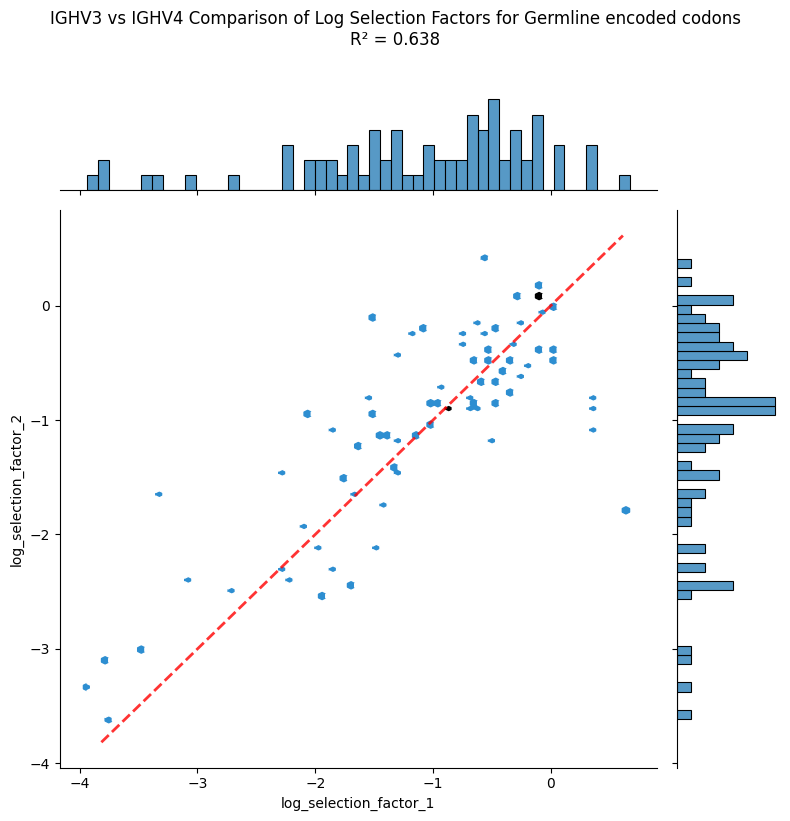

<Figure size 700x500 with 0 Axes>

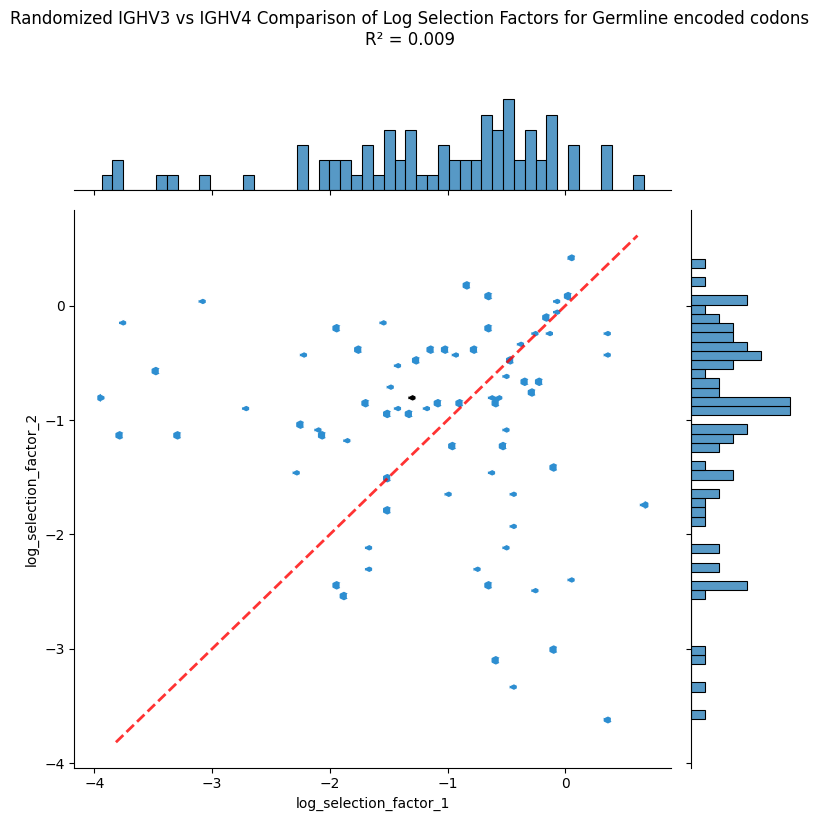

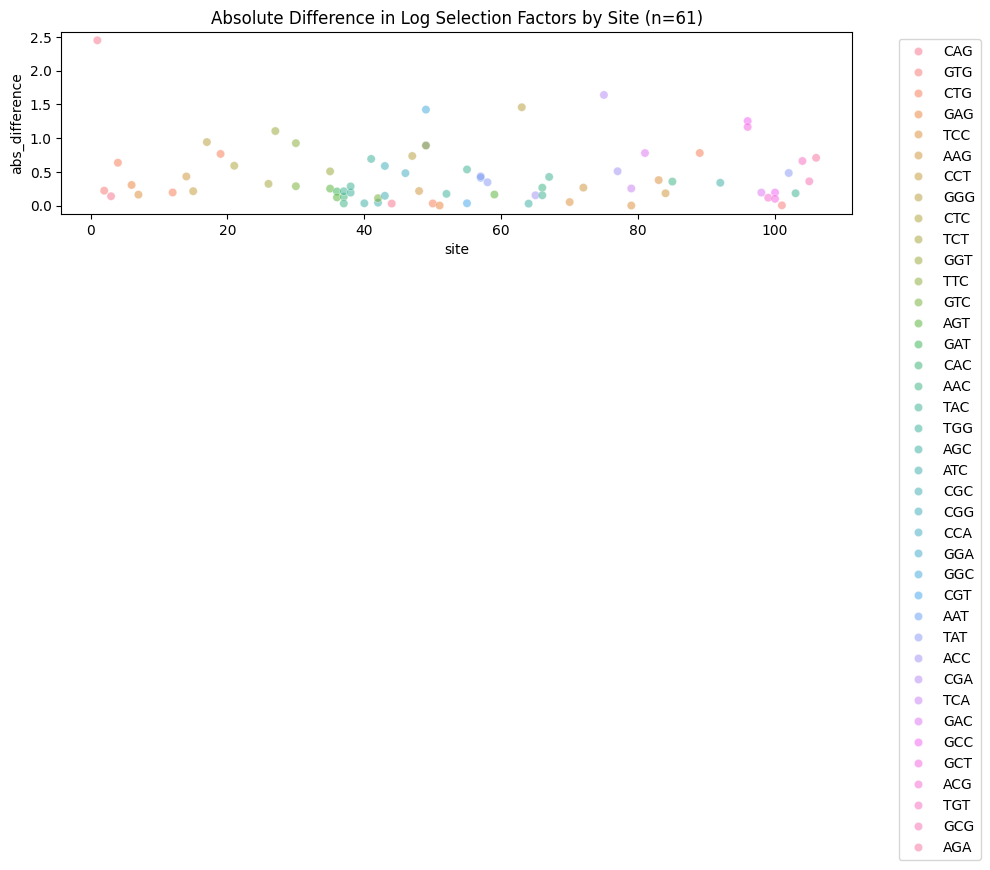

,site,parent_aa,parent_codon,log_selection_factor_1,log_selection_factor_2
0,1.0,Q,CAG,0.668675,-1.779291
1,2.0,V,GTG,-0.665727,-0.888172
2,3.0,Q,CAG,-0.661207,-0.801349
3,4.0,L,CTG,-1.499879,-2.136145
4,6.0,E,GAG,-1.425017,-1.731857
...,...,...,...,...,...
72,102.0,Y,TAT,-3.469807,-2.985412
73,103.0,Y,TAC,-1.013516,-0.828880
74,104.0,C,TGT,-3.081521,-2.419714
75,105.0,A,GCG,-0.273255,-0.633991


In [10]:
compare_v_families(site_sub_probs_df_germline, 'IGHV3', 'IGHV4', vcolumn='v_family', codons_or_aa='codons', lower_log_selection_factor_lim=-4, create_randomized=True)

<Figure size 700x500 with 0 Axes>

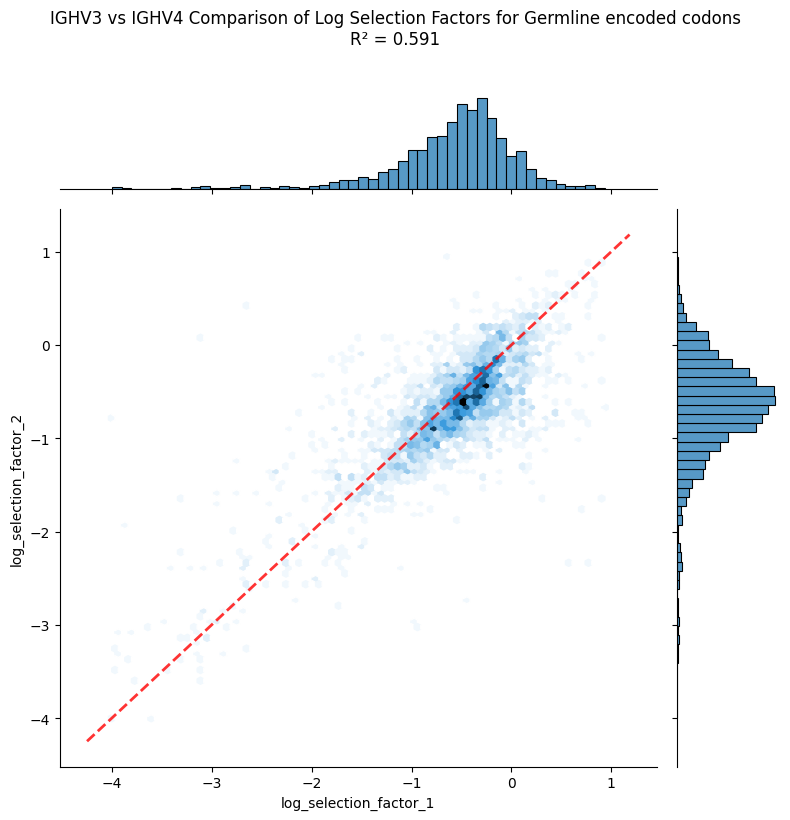

<Figure size 700x500 with 0 Axes>

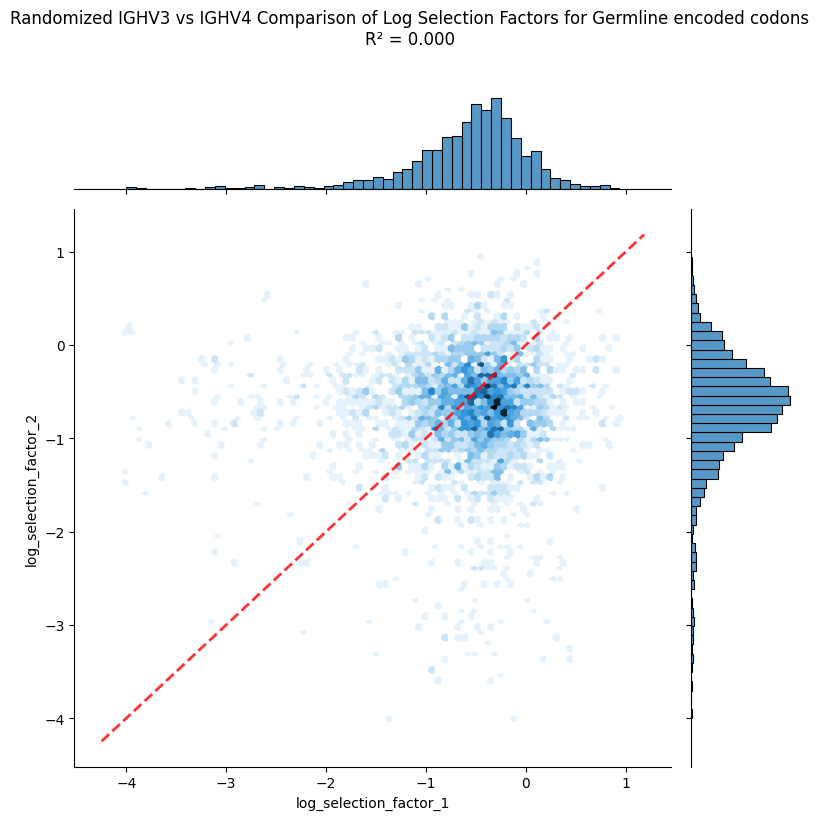

/tmp/ipykernel_2007874/666222498.py:145: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


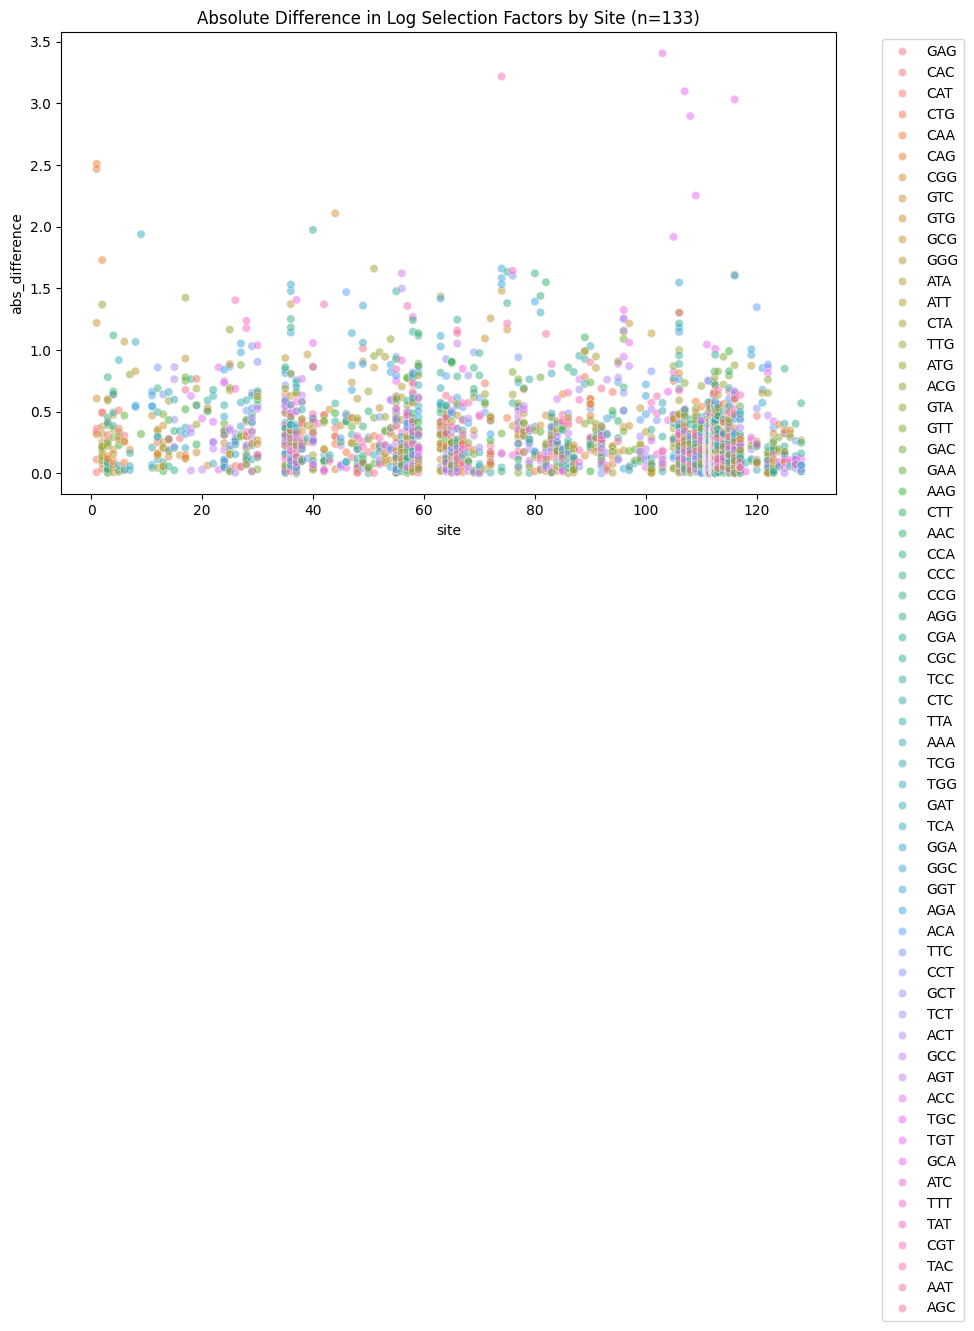

,site,parent_aa,parent_codon,log_selection_factor_1,log_selection_factor_2
0,1.0,E,GAG,-0.674530,-0.312623
1,1.0,H,CAC,0.546583,0.211238
2,1.0,H,CAT,0.383238,0.392073
3,1.0,L,CTG,0.259977,0.147332
4,1.0,Q,CAA,0.873672,-1.636512
...,...,...,...,...,...
2803,128.0,S,TCA,0.119709,0.061995
2804,128.0,S,TCC,0.108904,0.046361
2805,128.0,S,TCG,0.107780,0.092118
2806,128.0,S,TCT,0.087926,0.058307


In [11]:
compare_v_families(site_sub_probs_df_germline, 'IGHV3', 'IGHV4', vcolumn='v_family', is_germline=False, codons_or_aa='codons', lower_log_selection_factor_lim=-4, create_randomized=True)

<Figure size 700x500 with 0 Axes>

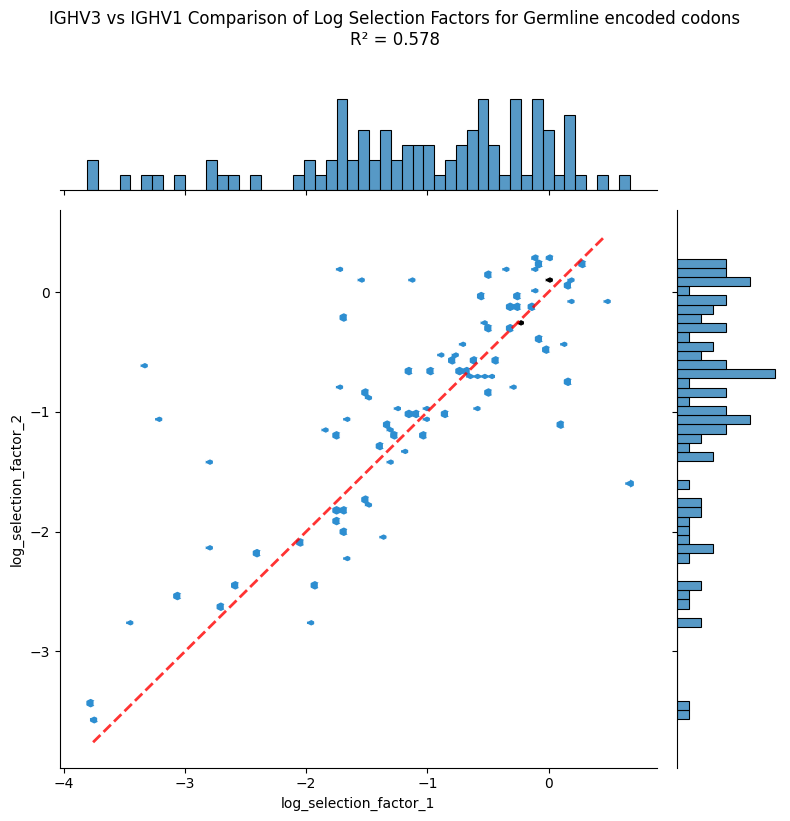

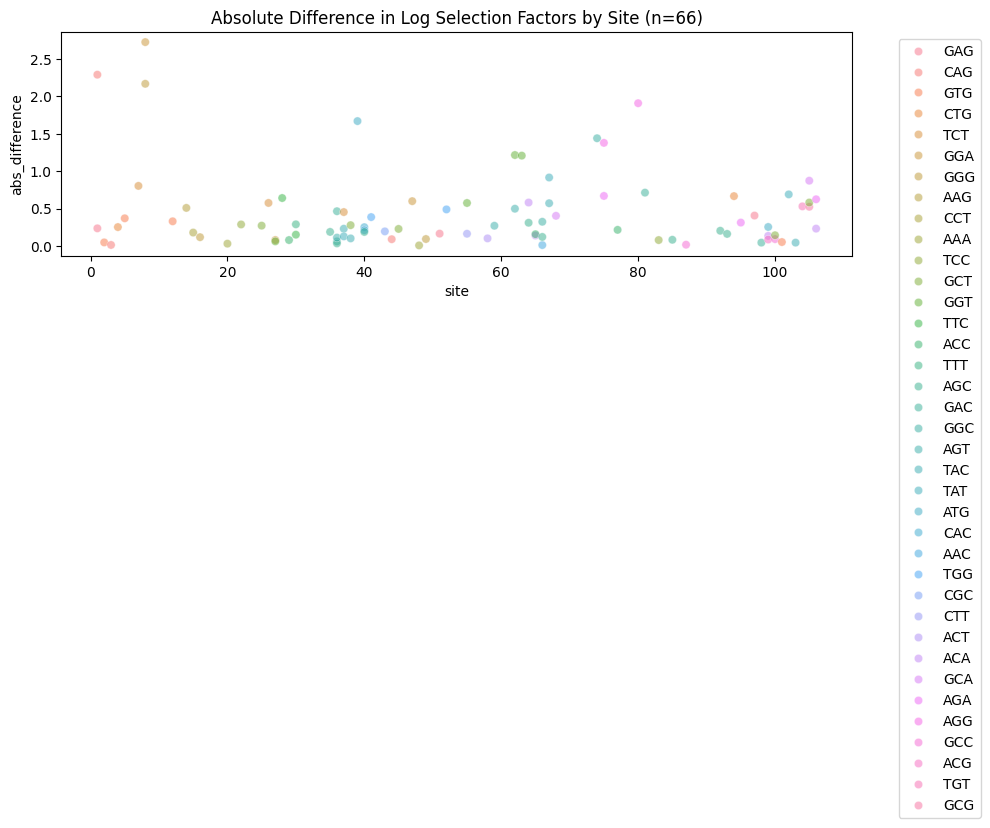

In [28]:
cur_df = compare_v_families(site_sub_probs_df_germline, 'IGHV3', 'IGHV1', codons_or_aa='codons')


In [ ]:
cur_df

,site,parent_aa,parent_codon,log_selection_factor_1,log_selection_factor_2
0,1.0,E,GAG,-0.674530,-0.437855
1,1.0,Q,CAG,0.668675,-1.618882
2,2.0,V,GTG,-0.665727,-0.714499
3,3.0,Q,CAG,-0.661207,-0.646395
4,4.0,L,CTG,-1.499879,-1.753146
...,...,...,...,...,...
87,105.0,A,GCA,0.145202,-0.727345
88,105.0,A,GCG,-0.273255,-0.797633
89,105.0,A,GCT,0.133109,-0.447950
90,106.0,R,AGA,-0.478765,0.145761


/tmp/ipykernel_1579713/4177110238.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  germline_codons_df[germline_codons_df.site == 8.0][germline_codons_df.v_family.isin(['IGHV1', 'IGHV3'])]


,site,codon,v_gene,v_family,amino_acid
7,8.0,GGA,IGHV1-18*01,IGHV1,G
105,8.0,GGA,IGHV1-18*03,IGHV1,G
203,8.0,GGA,IGHV1-18*04,IGHV1,G
301,8.0,GGG,IGHV1-2*02,IGHV1,G
399,8.0,GGG,IGHV1-2*04,IGHV1,G
...,...,...,...,...,...
12966,8.0,GGG,IGHV3-9*01,IGHV3,G
13065,8.0,GGG,IGHV3-9*02,IGHV3,G
13164,8.0,GGG,IGHV3-9*03,IGHV3,G
13263,8.0,GGG,IGHV3-9*04,IGHV3,G


<Figure size 700x500 with 0 Axes>

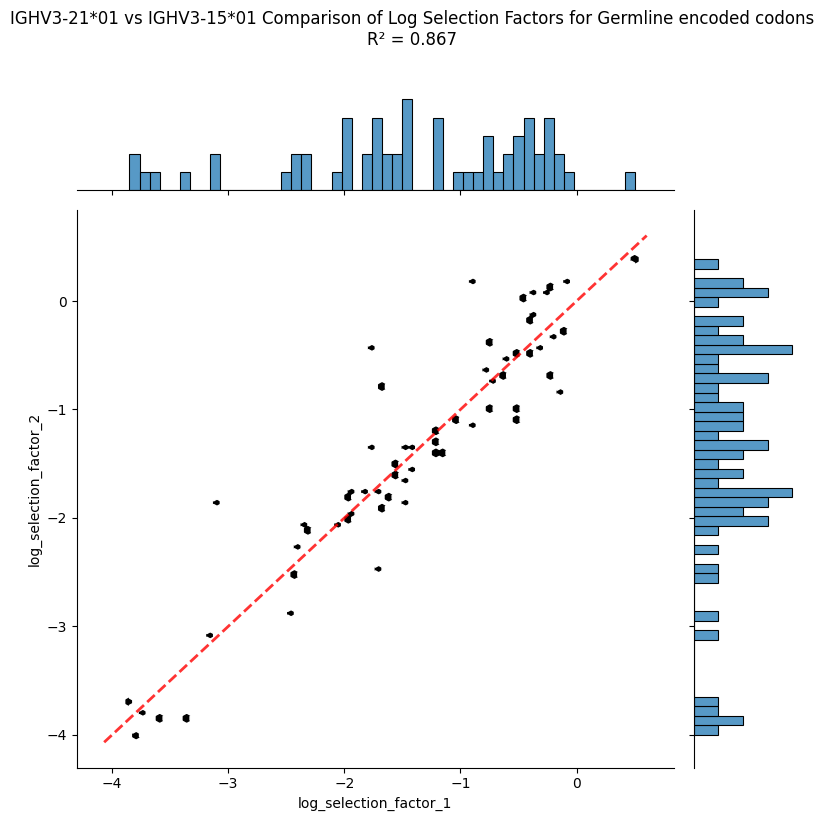

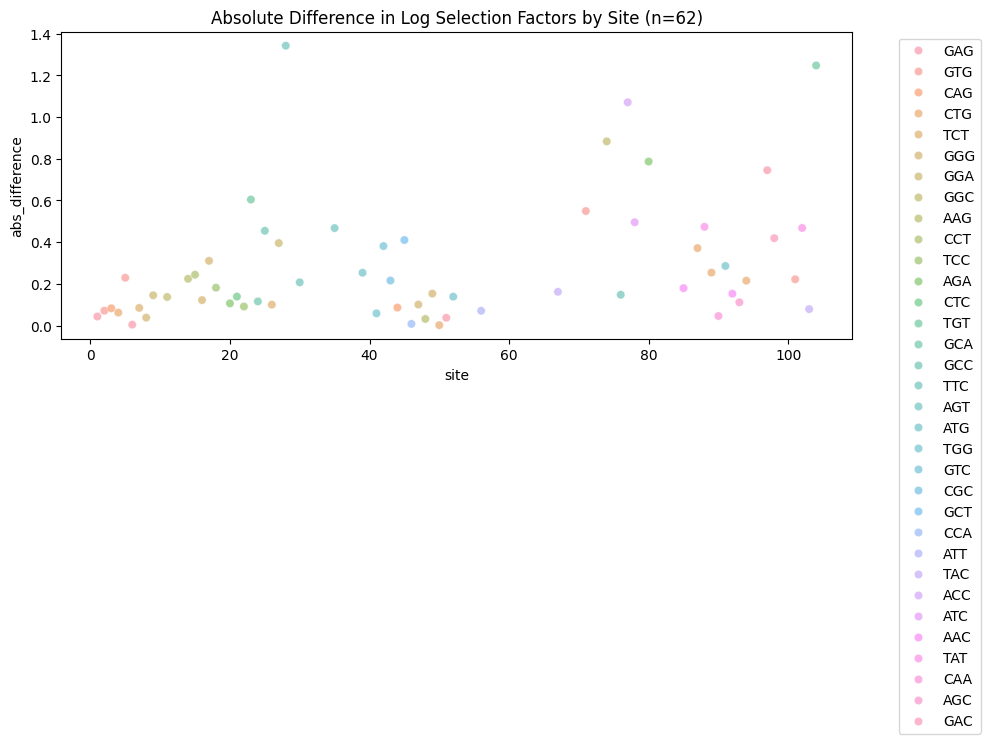

,site,parent_aa,parent_codon,log_selection_factor_1,log_selection_factor_2
0,1.0,E,GAG,-0.592196,-0.548953
1,2.0,V,GTG,-0.414370,-0.485648
2,3.0,Q,CAG,-0.615509,-0.698102
3,4.0,L,CTG,-1.557212,-1.495195
4,5.0,V,GTG,-0.740404,-0.969667
...,...,...,...,...,...
57,98.0,D,GAC,-2.467750,-2.887039
58,101.0,V,GTG,-0.053720,0.168145
59,102.0,Y,TAT,-3.359749,-3.827998
60,103.0,Y,TAC,-1.021428,-1.100123


In [30]:
compare_v_families(site_sub_probs_df_germline, 'IGHV3-21*01', 'IGHV3-15*01', codons_or_aa='codons', vcolumn='v_gene')


<Figure size 700x500 with 0 Axes>

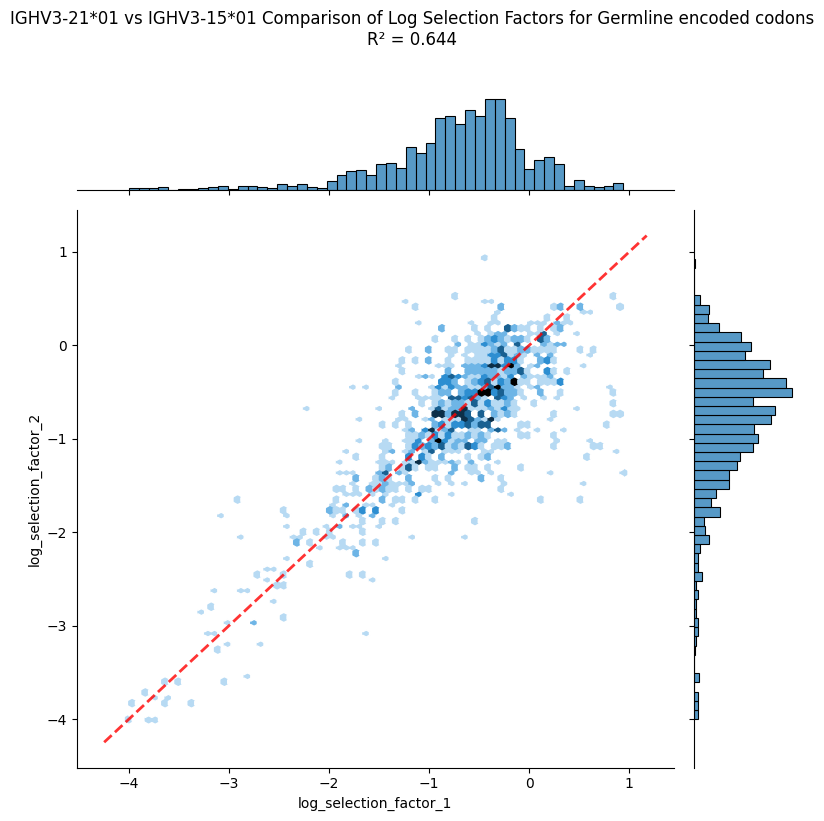

/tmp/ipykernel_2007874/666222498.py:145: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


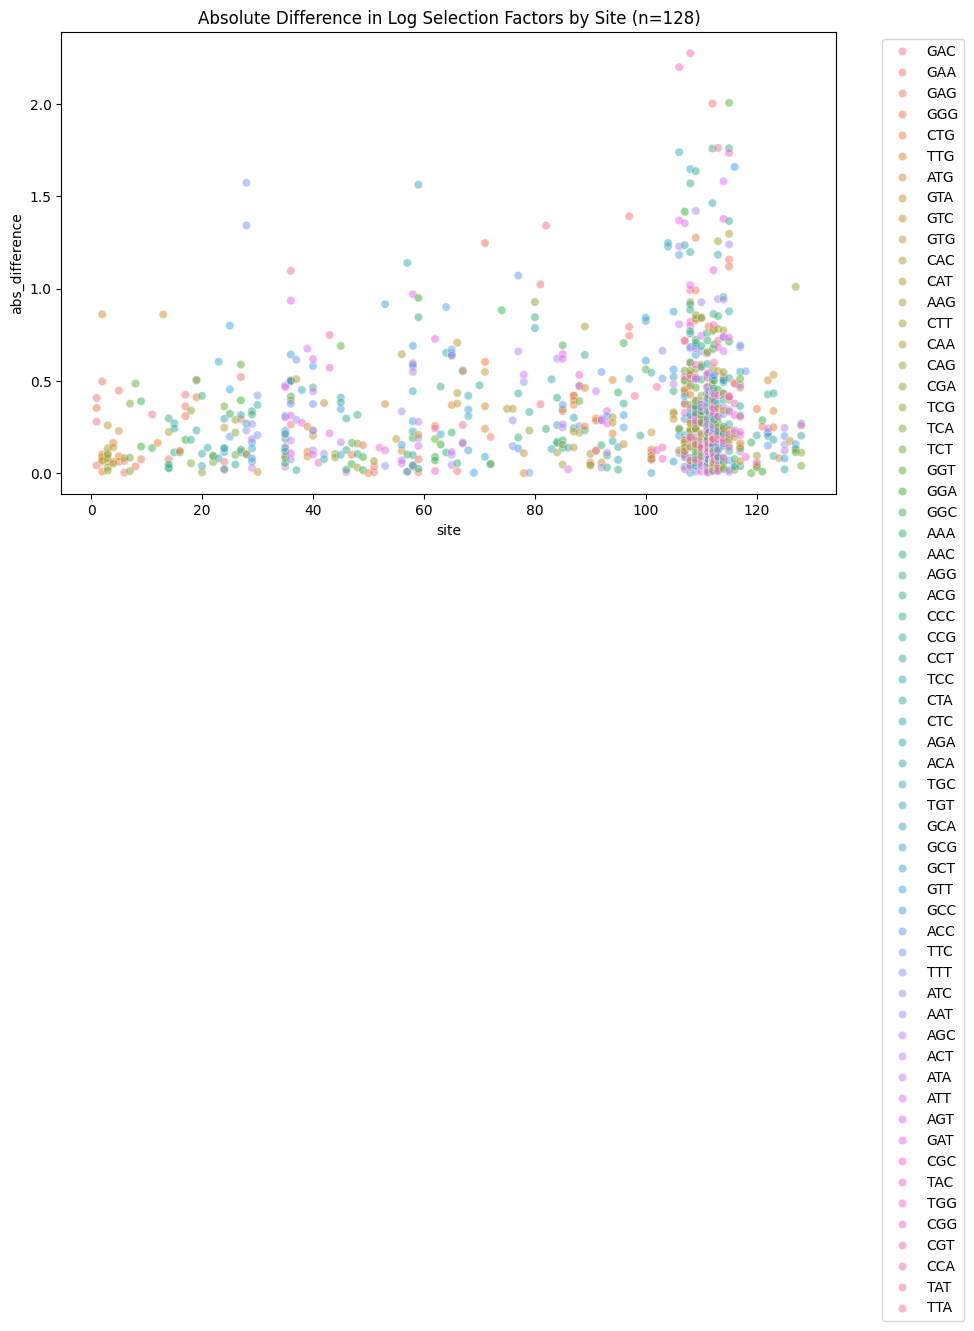

,site,parent_aa,parent_codon,log_selection_factor_1,log_selection_factor_2
0,1.0,D,GAC,-0.332484,-0.612655
1,1.0,E,GAA,-0.166565,-0.574630
2,1.0,E,GAG,-0.592196,-0.548953
3,1.0,G,GGG,0.872153,0.518055
4,2.0,E,GAG,-0.549987,-1.047784
...,...,...,...,...,...
973,128.0,A,GCA,-0.300040,-0.569565
974,128.0,P,CCA,0.185184,-0.073574
975,128.0,S,TCA,0.152053,0.110887
976,128.0,S,TCC,0.144022,-0.059907


In [12]:
compare_v_families(site_sub_probs_df_germline, 'IGHV3-21*01', 'IGHV3-15*01', codons_or_aa='codons', vcolumn='v_gene', is_germline=False)


<Figure size 700x500 with 0 Axes>

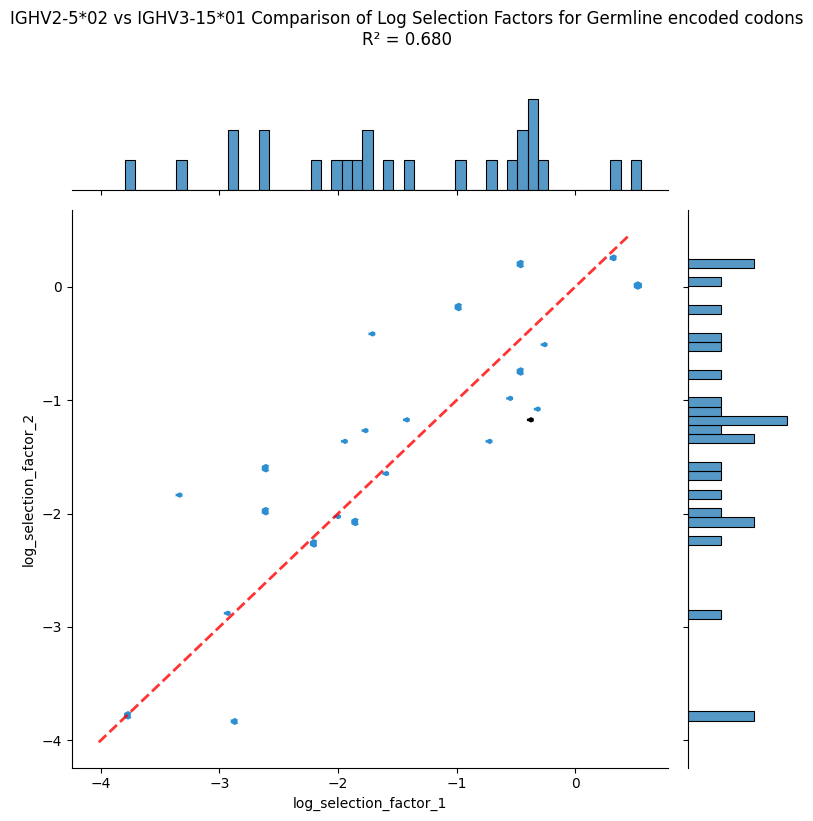

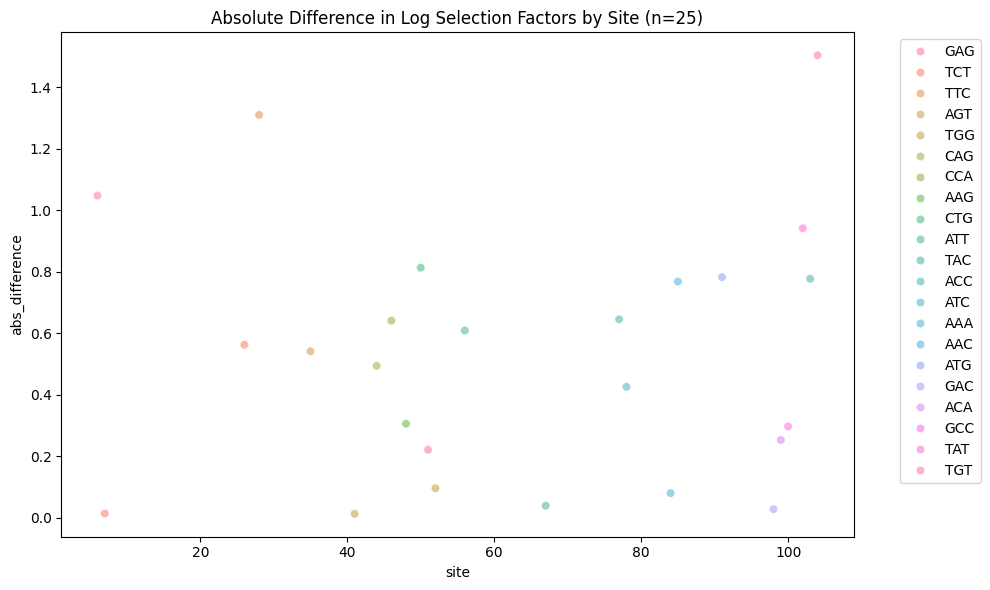

In [31]:
cur_df = compare_v_families(site_sub_probs_df_germline, 'IGHV2-5*02', 'IGHV3-15*01', codons_or_aa='codons', vcolumn='v_gene')



<Figure size 700x500 with 0 Axes>

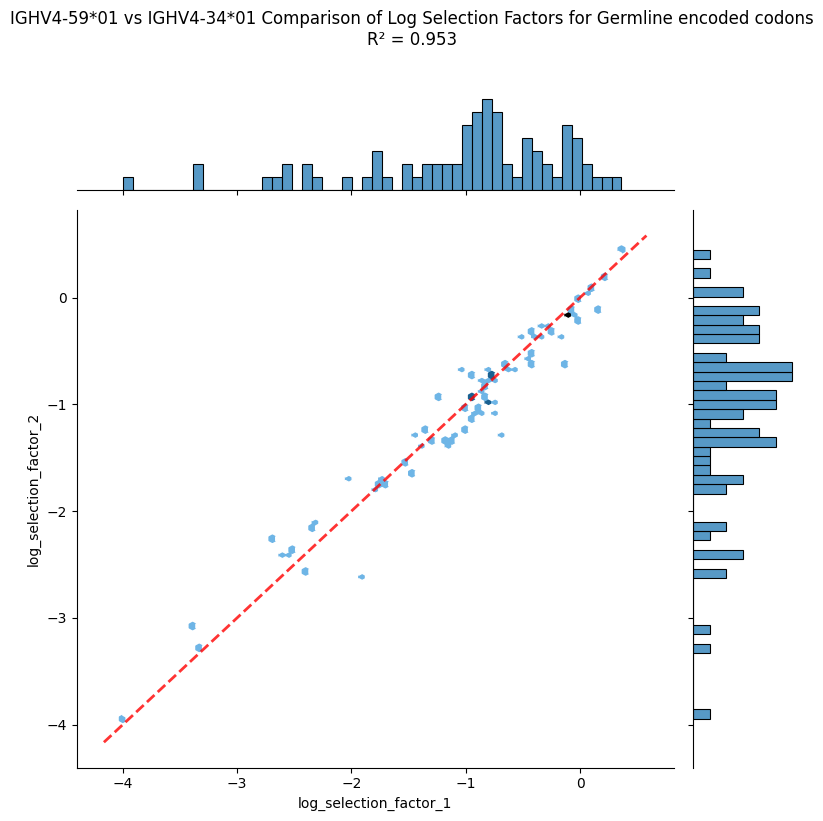

<Figure size 700x500 with 0 Axes>

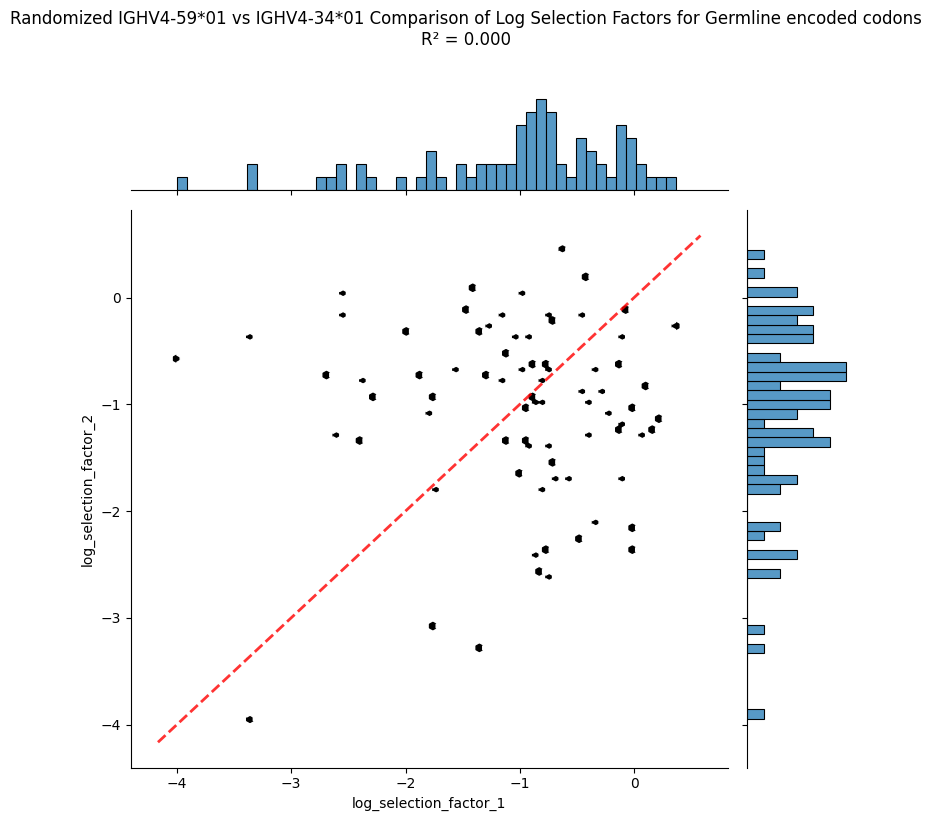

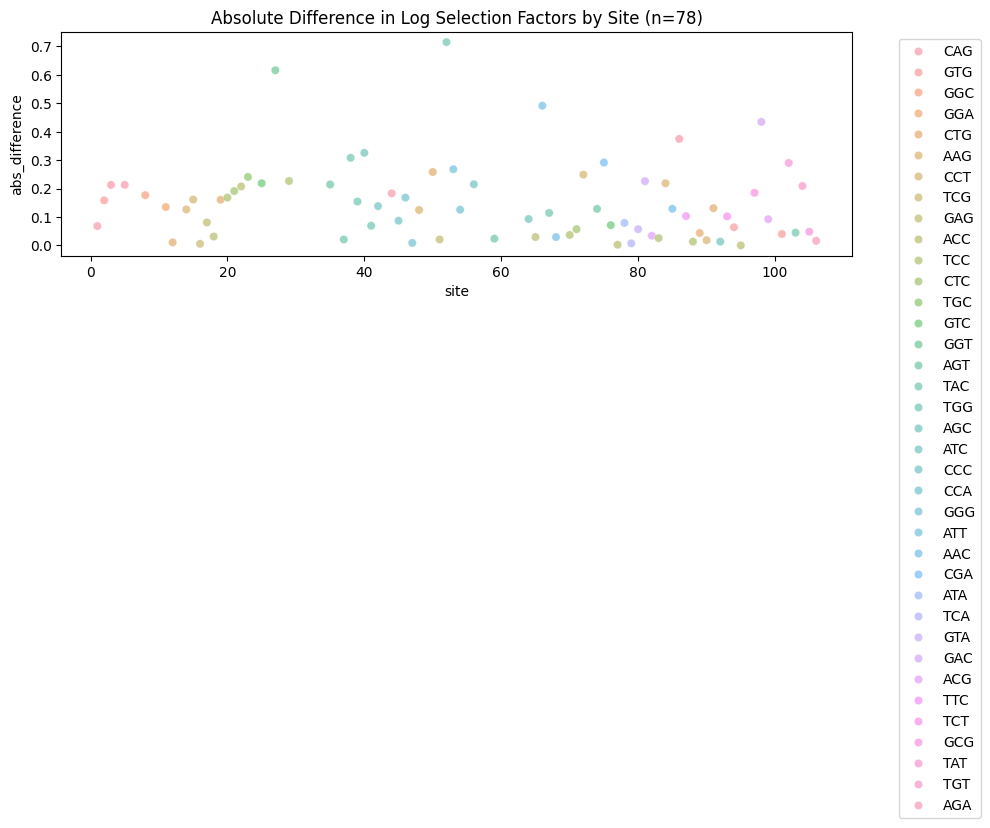

In [35]:
cur_df = compare_v_families(site_sub_probs_df_germline, 'IGHV4-59*01', 'IGHV4-34*01', codons_or_aa='codons', vcolumn='v_gene', create_randomized=True)


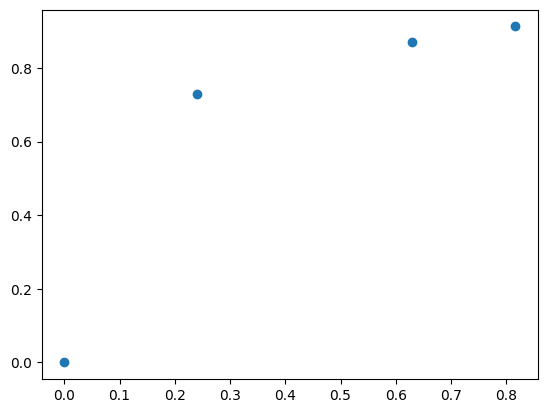

In [36]:
plt.scatter([0.63,0.24,0.816, 0], [0.87, 0.73, 0.913, 0])

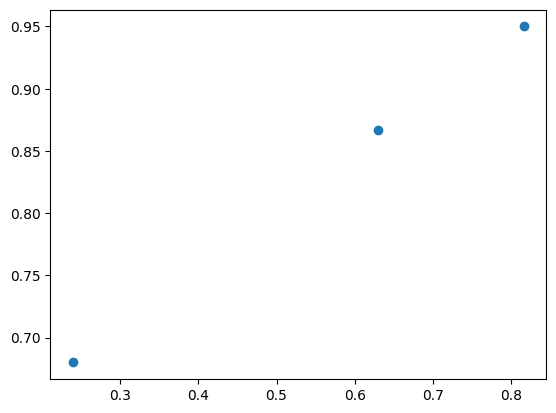

In [34]:
plt.scatter([0.63,0.24,0.816], [0.867, 0.68, 0.95])

### how diverged are the different families?


/tmp/ipykernel_15317/2160548233.py:46: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  numeric_pivot = pivot_data.applymap(lambda x: codon_to_num.get(x, -1))
/tmp/ipykernel_15317/2160548233.py:89: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


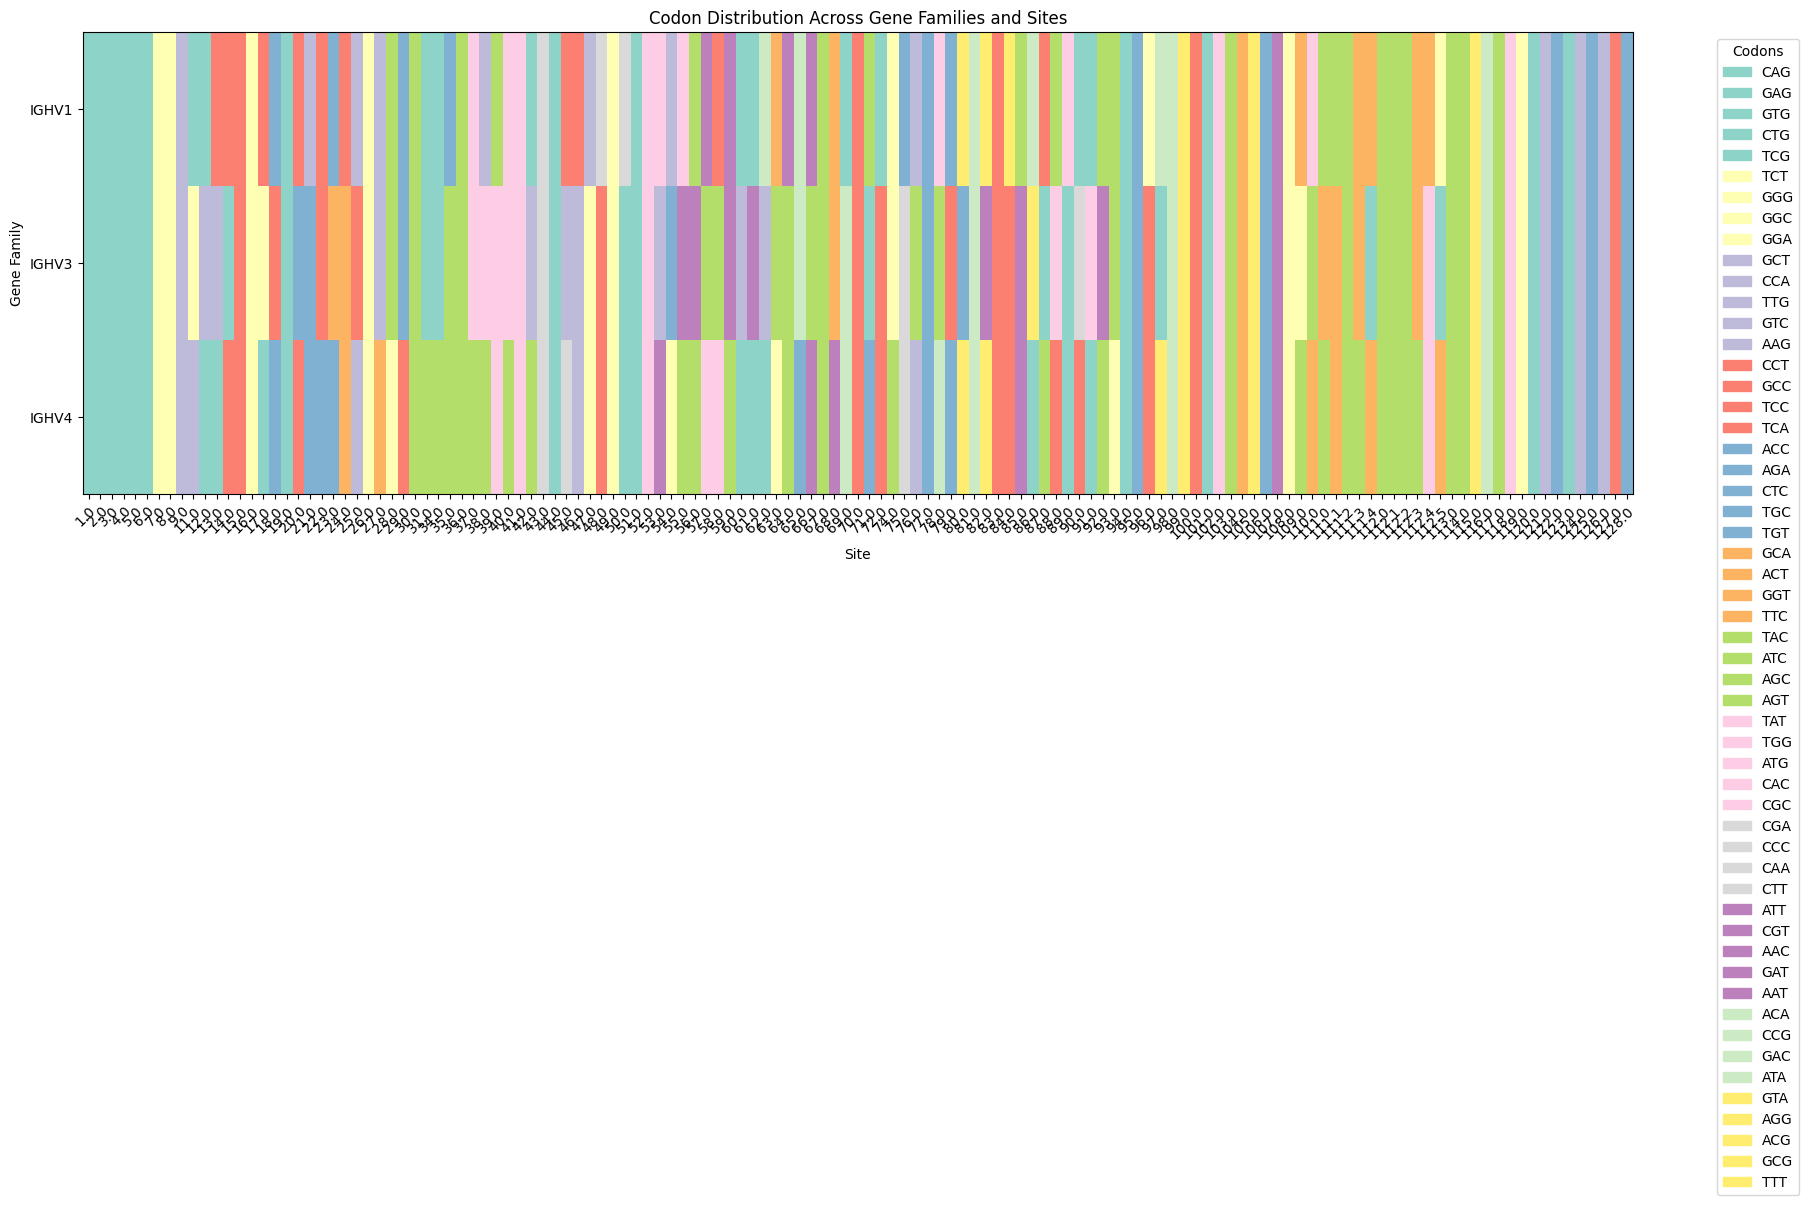

In [ ]:
import matplotlib.patches as mpatches

def plot_codon_heatmap(df, gene_family_column='gene_family', site_column='site', parent_codon_column='parent_codon'):
    """
    Create a colored heatmap showing the distribution of parent codons 
    across different gene families and sites.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe containing gene family, site, and parent codon information
    gene_family_column : str, optional
        Column name for gene families, default: 'gene_family'
    site_column : str, optional
        Column name for sites, default: 'site'
    parent_codon_column : str, optional
        Column name for parent codons, default: 'parent_codon'
    
    Returns:
    --------
    tuple
        (fig, ax) - The figure and axis objects
    """
    # Pivot the data to create a matrix of gene families, sites, and codons
    pivot_data = df.pivot_table(
        index=gene_family_column, 
        columns=site_column, 
        values=parent_codon_column, 
        aggfunc='first'
    )
    
    # Get unique codons for color mapping
    unique_codons = df[parent_codon_column].unique()
    
    # Create a color palette
    # Use a colorblind-friendly palette with enough distinct colors
    codon_colors = plt.cm.Set3(np.linspace(0, 1, len(unique_codons)))
    codon_color_dict = dict(zip(unique_codons, codon_colors))
    
    # Create the figure and axes
    fig, ax = plt.subplots(figsize=(20, 6))
    
    # Create a custom color-coded heatmap
    # Start by creating a numeric mapping of codons
    codon_to_num = {codon: i for i, codon in enumerate(unique_codons)}
    numeric_pivot = pivot_data.applymap(lambda x: codon_to_num.get(x, -1))
    
    # Plot the heatmap
    im = ax.imshow(numeric_pivot, cmap=plt.cm.Set3, aspect='auto')
    
    # Set ticks
    ax.set_xticks(np.arange(len(pivot_data.columns)))
    ax.set_yticks(np.arange(len(pivot_data.index)))
    ax.set_xticklabels(pivot_data.columns)
    ax.set_yticklabels(pivot_data.index)
    
    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    # Add text annotations
    # for i in range(len(pivot_data.index)):
    #     for j in range(len(pivot_data.columns)):
    #         text = pivot_data.iloc[i, j]
    #         ax.text(j, i, str(text), 
    #                 ha="center", va="center", 
    #                 color="black" if text is not np.nan else "white")
    
    # Create a custom colorbar
    # Create a list of patches for the legend
    legend_patches = [
        mpatches.Patch(color=codon_color_dict[codon], label=codon) 
        for codon in unique_codons
    ]
    
    # Add the legend
    plt.legend(
        handles=legend_patches, 
        title="Codons", 
        bbox_to_anchor=(1.05, 1), 
        loc='upper left'
    )
    
    # Set title and labels
    plt.title("Codon Distribution Across Gene Families and Sites")
    plt.xlabel("Site")
    plt.ylabel("Gene Family")
    
    # Adjust layout to prevent cutting off labels
    plt.tight_layout()
    
    return fig, ax

# Example usage:
# fig, ax = plot_codon_heatmap(most_common_codon_vfam_df)

# Example usage:
fig, ax = plot_codon_heatmap(most_common_codon_vfam_df[most_common_codon_vfam_df.gene_family.isin(['IGHV3', 'IGHV4', 'IGHV1'])])

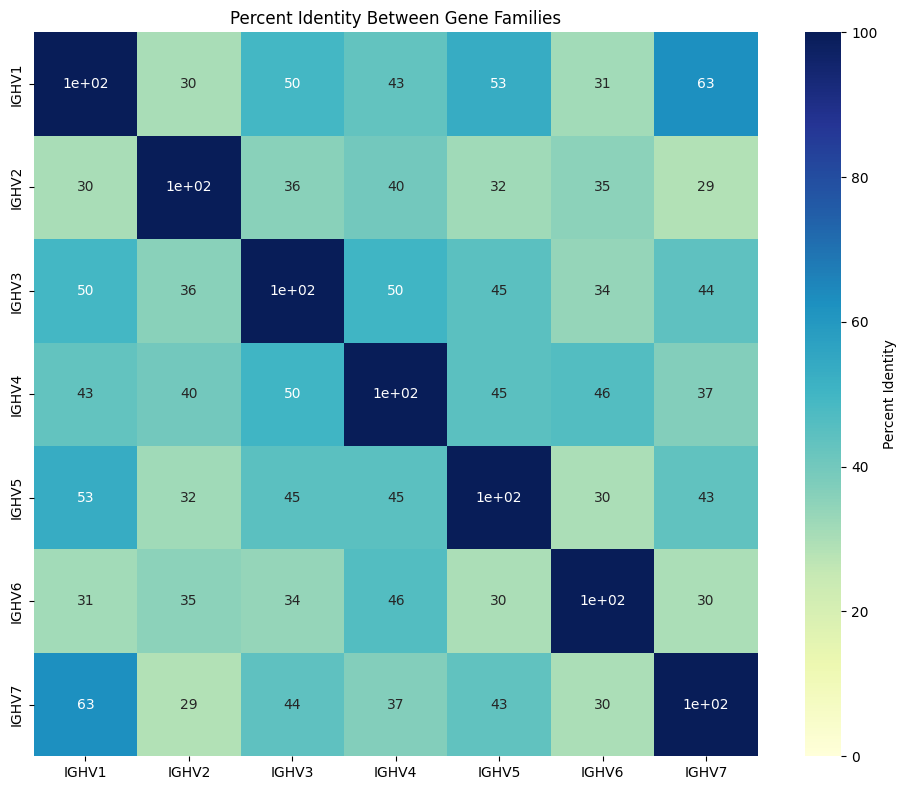

In [ ]:
def calculate_family_percent_identity(df, gene_family_column='gene_family', site_column='site', parent_codon_column='parent_codon'):
    """
    Calculate percent identity between every pair of gene families based on their codons.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe containing gene family, site, and parent codon information
    gene_family_column : str, optional
        Column name for gene families, default: 'gene_family'
    site_column : str, optional
        Column name for sites, default: 'site'
    parent_codon_column : str, optional
        Column name for parent codons, default: 'parent_codon'
    
    Returns:
    --------
    pandas.DataFrame
        Symmetric matrix of percent identities between gene families
    """
    # Pivot the data to create a matrix of gene families, sites, and codons
    pivot_data = df.pivot_table(
        index=gene_family_column, 
        columns=site_column, 
        values=parent_codon_column, 
        aggfunc='first'
    )
    
    # Get list of unique families
    families = pivot_data.index.tolist()
    
    # Create a DataFrame to store percent identities
    percent_identity_matrix = pd.DataFrame(
        index=families, 
        columns=families, 
        dtype=float
    )
    
    # Calculate percent identity for each pair of families
    for i, family1 in enumerate(families):
        for j, family2 in enumerate(families):
            # Skip comparing a family to itself
            if i == j:
                percent_identity_matrix.loc[family1, family2] = 100.0
                continue
            
            # Get codons for both families
            family1_codons = pivot_data.loc[family1].dropna()
            family2_codons = pivot_data.loc[family2].dropna()
            
            # Find common sites
            common_sites = set(family1_codons.index) & set(family2_codons.index)
            
            # Calculate identity
            if not common_sites:
                percent_identity_matrix.loc[family1, family2] = 0.0
                continue
            
            # Count matching codons
            matching_codons = sum(
                family1_codons.loc[site] == family2_codons.loc[site] 
                for site in common_sites
            )
            
            # Calculate percent identity
            percent_identity = (matching_codons / len(common_sites)) * 100
            
            # Store in both symmetric positions
            percent_identity_matrix.loc[family1, family2] = percent_identity
            percent_identity_matrix.loc[family2, family1] = percent_identity
    
    return percent_identity_matrix

def plot_percent_identity_heatmap(percent_identity_matrix):
    """
    Create a heatmap visualization of the percent identity matrix.
    
    Parameters:
    -----------
    percent_identity_matrix : pandas.DataFrame
        Matrix of percent identities between gene families
    
    Returns:
    --------
    tuple
        (fig, ax) - The figure and axis objects
    """
    # Create the figure and axes
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Create the heatmap
    sns.heatmap(
        percent_identity_matrix, 
        annot=True,  # Show the actual values
        cmap='YlGnBu',  # Color palette
        center=50,  # Center the colormap at 50%
        vmin=0,  # Minimum value
        vmax=100,  # Maximum value
        square=True,  # Make the plot square
        cbar_kws={'label': 'Percent Identity'}
    )
    
    plt.title('Percent Identity Between Gene Families')
    plt.tight_layout()
    
    return fig, ax

# Example usage:
percent_identity = calculate_family_percent_identity(most_common_codon_vfam_df)
fig, ax = plot_percent_identity_heatmap(percent_identity)
# plt.show()

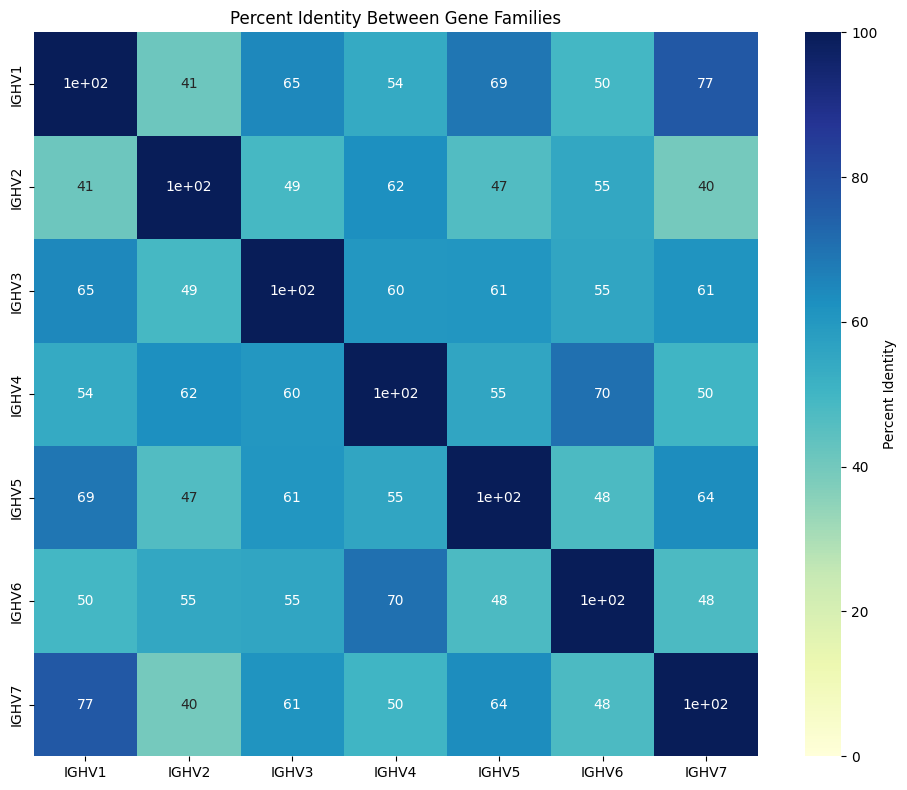

In [ ]:
percent_identity = calculate_family_percent_identity(most_common_aa_vfam_df, parent_codon_column='parent_aa')
fig, ax = plot_percent_identity_heatmap(percent_identity)
plt.show()

In [ ]:


germline_df = pd.read_csv("../data/human_ighv_aa_seqs.csv")

# drop any rows where the "sequence" column contains either a `*` or a `X`
germline_df = germline_df[~germline_df["sequence"].str.contains("[*X]")].reset_index(drop=True)

germline_df["v_family"] = germline_df["gene"].str.split("-", expand=True)[0]

max_len = max(germline_df["sequence"].apply(len))
# pad sequences with `-` to make them all the same length
germline_df["sequence"] = germline_df["sequence"].apply(lambda x: x + "-"*(max_len - len(x)))

FileNotFoundError: [Errno 2] No such file or directory: '../data/human_ighv_aa_seqs.csv'

## counts based approach

In [ ]:
site_sub_probs_df.groupby(['sample_id', 'family', 'site']).mutation.max().reset_index().groupby('site').mutation.mean()

site
1.0      0.062105
2.0      0.095220
3.0      0.142507
4.0      0.048447
5.0      0.088262
           ...   
124.0    0.026930
125.0    0.130009
126.0    0.008762
127.0    0.025126
128.0    0.055019
Name: mutation, Length: 144, dtype: float64

In [ ]:
site_sub_probs_df.groupby(['v_family', 'sample_id', 'family', 'site']).mutation.max().reset_index().groupby(['v_family', 'site']).mutation.mean().reset_index()

,v_family,site,mutation
0,IGHV1,1.0,0.042473
1,IGHV1,2.0,0.089944
2,IGHV1,3.0,0.158026
3,IGHV1,4.0,0.049969
4,IGHV1,5.0,0.115553
...,...,...,...
944,IGHV7,124.0,0.020833
945,IGHV7,125.0,0.083333
946,IGHV7,126.0,0.020833
947,IGHV7,127.0,0.020833


<Axes: >

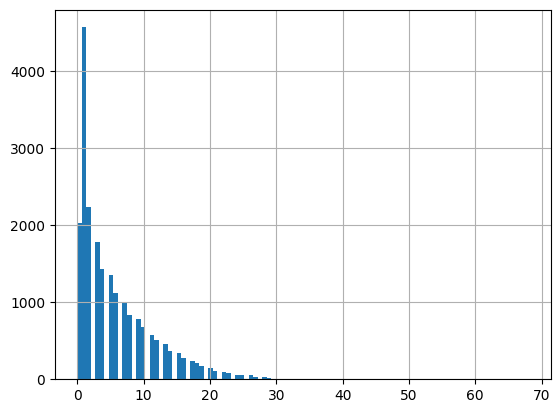

In [ ]:
# distribution of mutations count per pcp
site_sub_probs_df.groupby('pcp_index').mutation.sum().hist(bins=100)

<Axes: xlabel='site'>

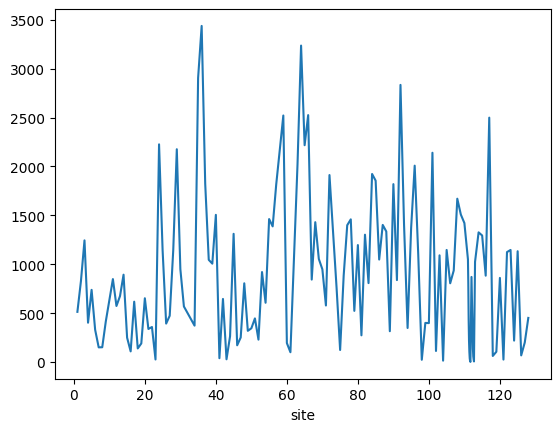

In [ ]:
# distribution of mutation counts per site
site_sub_probs_df[site_sub_probs_df.mutation == True].groupby(['site']).size().plot()

<Axes: xlabel='site'>

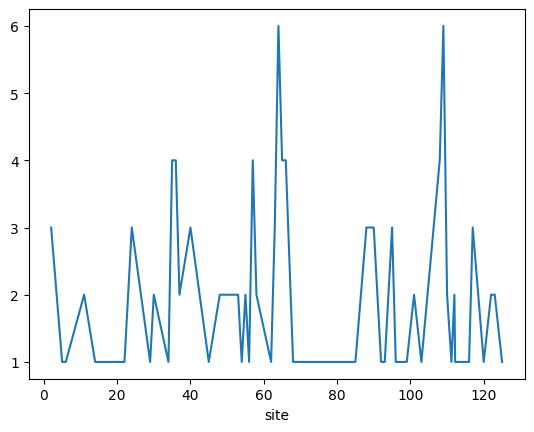

In [ ]:
site_sub_probs_df[site_sub_probs_df.family == 1401]
site_sub_probs_df[(site_sub_probs_df.mutation == True) & (site_sub_probs_df.family == 1401)].groupby(['site']).size().plot()

In [ ]:
site_sub_probs_df[site_sub_probs_df.family == 1401].pcp_index.nunique()

20

In [ ]:
site_sub_probs_df[(site_sub_probs_df.family == 1401)]

,neutral_prob,selection_factor,prob,mutation,pcp_index,site,is_cdr,parent_codon,parent_aa,child_codon,child_aa,v_gene_h,j_gene,v_family,j_family,sample_id,family
0,0.118513,0.078600,0.009315,False,0,1.0,False,CAG,Q,CAG,Q,IGHV7-4-1*02,IGHJ4*02,IGHV7,IGHJ4,sample-igg-SC-24,1401
1,0.035649,0.078600,0.002802,False,1,1.0,False,CAG,Q,CAG,Q,IGHV7-4-1*02,IGHJ4*02,IGHV7,IGHJ4,sample-igg-SC-24,1401
2567,0.182620,0.334433,0.061074,False,2567,1.0,False,CAG,Q,CAG,Q,IGHV4-30-2*01,IGHJ4*02,IGHV4,IGHJ4,sample-igg-SC-17,1401
2568,0.096536,0.273699,0.026422,False,2568,1.0,False,CAG,Q,CAG,Q,IGHV4-30-2*01,IGHJ4*02,IGHV4,IGHJ4,sample-igg-SC-17,1401
2569,0.024198,0.273699,0.006623,False,2569,1.0,False,CAG,Q,CAG,Q,IGHV4-30-2*01,IGHJ4*02,IGHV4,IGHJ4,sample-igg-SC-17,1401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2636533,0.027005,0.725953,0.019604,False,11898,128.0,False,TCA,S,TCA,S,IGHV3-23*01,IGHJ3*02,IGHV3,IGHJ3,sample-igg-W-103,1401
2636534,0.019640,0.725953,0.014258,False,11899,128.0,False,TCA,S,TCA,S,IGHV3-23*01,IGHJ3*02,IGHV3,IGHJ3,sample-igg-W-103,1401
2636535,0.012650,0.725953,0.009183,False,11900,128.0,False,TCA,S,TCA,S,IGHV3-23*01,IGHJ3*02,IGHV3,IGHJ3,sample-igg-W-103,1401
2640219,0.021809,0.625922,0.013650,False,15589,128.0,False,TCA,S,TCA,S,IGHV4-34*01,IGHJ4*02,IGHV4,IGHJ4,sample-igg-W-19,1401


In [ ]:
pcp_df[(site_sub_probs_df.sample_id == 'sample-igg-W-103') & (pcp_df.family == 1401)]

/tmp/ipykernel_14822/4172473784.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pcp_df[(site_sub_probs_df.sample_id == 'sample-igg-W-103') & (pcp_df.family == 1401)]


,orig_pcp_idx,sample_id,family,parent_name,child_name,branch_length,depth,distance,parent_is_naive,child_is_leaf,...,cdr2_codon_end,cdr3_codon_start,cdr3_codon_end,v_family,nt_rates,nt_csps,parent_aa,j_gene,v_gene_h,j_family
11889,195049,sample-igg-W-103,1401,Node1,1GTGGTGAGGAAT,0.055074,2,0.067365,False,True,...,171.0,288.0,327.0,IGHV3,"tensor([0.4659, 0.6480, 1.1762, 0.5008, 0.6850...","tensor([[0.1922, 0.4680, 0.0000, 0.3398],\n ...",EVQLLESGGGLVQPGGSLRLSCAASGFTFSNYAMSWVRQAPGKGLE...,IGHJ3*02,IGHV3-23*01,IGHJ3
11890,195050,sample-igg-W-103,1401,Node1,Node2,0.020677,2,0.032967,False,False,...,171.0,288.0,327.0,IGHV3,"tensor([0.4659, 0.6480, 1.1762, 0.5008, 0.6850...","tensor([[0.1922, 0.4680, 0.0000, 0.3398],\n ...",EVQLLESGGGLVQPGGSLRLSCAASGFTFSNYAMSWVRQAPGKGLE...,IGHJ3*02,IGHV3-23*01,IGHJ3
11891,195051,sample-igg-W-103,1401,Node2,1CGCCAATATCGC,0.067319,3,0.100287,False,True,...,171.0,288.0,327.0,IGHV3,"tensor([0.4659, 0.6480, 1.1762, 0.5008, 0.6850...","tensor([[0.1922, 0.4680, 0.0000, 0.3398],\n ...",EVQLLESGGGLVQPGGSLRLSCAASGFTFSNYAMSWVRQAPGKGLE...,IGHJ3*02,IGHV3-23*01,IGHJ3
11892,195052,sample-igg-W-103,1401,Node2,Node3,0.031260,3,0.064227,False,False,...,171.0,288.0,327.0,IGHV3,"tensor([0.4659, 0.6480, 1.1762, 0.5008, 0.6850...","tensor([[0.1922, 0.4680, 0.0000, 0.3398],\n ...",EVQLLESGGGLVQPGGSLRLSCAASGFTFSNYAMSWVRQAPGKGLE...,IGHJ3*02,IGHV3-23*01,IGHJ3
11893,195053,sample-igg-W-103,1401,Node3,Node4,0.041356,4,0.105583,False,False,...,171.0,288.0,327.0,IGHV3,"tensor([0.7965, 1.0768, 1.5411, 0.9170, 0.8454...","tensor([[0.2032, 0.4157, 0.0000, 0.3812],\n ...",EMQLLESGGGLVQPGGSLRLSCVASGFTFSNYAMSWVRQAPGKGLE...,IGHJ3*02,IGHV3-23*01,IGHJ3
11894,195054,sample-igg-W-103,1401,Node4,Node5,0.030383,5,0.135966,False,False,...,171.0,288.0,327.0,IGHV3,"tensor([0.7965, 1.0768, 1.5411, 0.9170, 0.8454...","tensor([[0.2032, 0.4157, 0.0000, 0.3812],\n ...",EMQLLESGGGLVQPGGSLRLSCVASGFTFSNYAMSWVRQAPGKGLE...,IGHJ3*02,IGHV3-23*01,IGHJ3
11895,195059,sample-igg-W-103,1401,Node4,2TTGAGCGGTTAC,0.026451,5,0.132034,False,True,...,171.0,288.0,327.0,IGHV3,"tensor([0.7965, 1.0768, 1.5411, 0.9170, 0.8454...","tensor([[0.2032, 0.4157, 0.0000, 0.3812],\n ...",EMQLLESGGGLVQPGGSLRLSCVASGFTFSNYAMSWVRQAPGKGLE...,IGHJ3*02,IGHV3-23*01,IGHJ3
11896,195060,sample-igg-W-103,1401,Node3,Node7,0.044684,4,0.108911,False,False,...,171.0,288.0,327.0,IGHV3,"tensor([0.7965, 1.0768, 1.5411, 0.9170, 0.8454...","tensor([[0.2032, 0.4157, 0.0000, 0.3812],\n ...",EMQLLESGGGLVQPGGSLRLSCVASGFTFSNYAMSWVRQAPGKGLE...,IGHJ3*02,IGHV3-23*01,IGHJ3
11897,195061,sample-igg-W-103,1401,Node7,Node8,0.004486,5,0.113397,False,False,...,171.0,288.0,327.0,IGHV3,"tensor([0.7965, 1.0768, 1.5411, 0.9170, 0.8454...","tensor([[0.2032, 0.4157, 0.0000, 0.3812],\n ...",EMQLLESGGGLVQPGGSLRLSCVASGFSFGNYAMNWVRQAPGKGLE...,IGHJ3*02,IGHV3-23*01,IGHJ3
11898,195062,sample-igg-W-103,1401,Node8,Node9,0.035519,6,0.148916,False,False,...,171.0,288.0,327.0,IGHV3,"tensor([0.7965, 1.0768, 1.5411, 0.9170, 0.8454...","tensor([[0.2032, 0.4157, 0.0000, 0.3812],\n ...",EMQLLESGGGLVQPGGSLRLSCVASGFSFGNYAMNWVRQAPGKGLE...,IGHJ3*02,IGHV3-23*01,IGHJ3


## Vanwinkle data

datasets in names datasets had a lot of N's in them, so I used this to filter:

(netam_env) nharel@ermine:~/re$ python pcp-pipeline/scripts/filter_pcp_with_N_and_naive.py ~/data/v1/vanwinkle-170-igh_pcp_2025-03-05_MASKED_NI_test_no-naive_DXSMVALID.csv.gz 
Saved to: /home/nharel/data/v1/vanwinkle-170-igh_pcp_2025-03-05_MASKED_NI_test_no-naive_DXSMVALID_noN_no-naive.csv.gz

also add branch length calculation

Loading /home/nharel/data/v1/vanwinkle-170-igh_pcp_2025-03-05_MASKED_NI_test_no-naive_DXSMVALID_noN_no-naive.csv.gz
Using cached models: /home/nharel/re/netam/netam/_pretrained/thrifty-0.2.0.zip
Using ThriftyHumV0.2-59 for neutral model on device None


Evaluating model: 100%|██████████| 2437/2437 [00:04<00:00, 551.93it/s] 


Loading model
Loading branch lengths


Calculating model predictions: 100%|██████████| 24/24 [02:35<00:00,  6.48s/it]


Preparing heavy chain plot data
ANARCI seq length mismatch! 888333863-igh 17035
Computing site substitution probabilities dataframe...
Computing site substitution probabilities dataframe...
Computing site substitution probabilities dataframe...


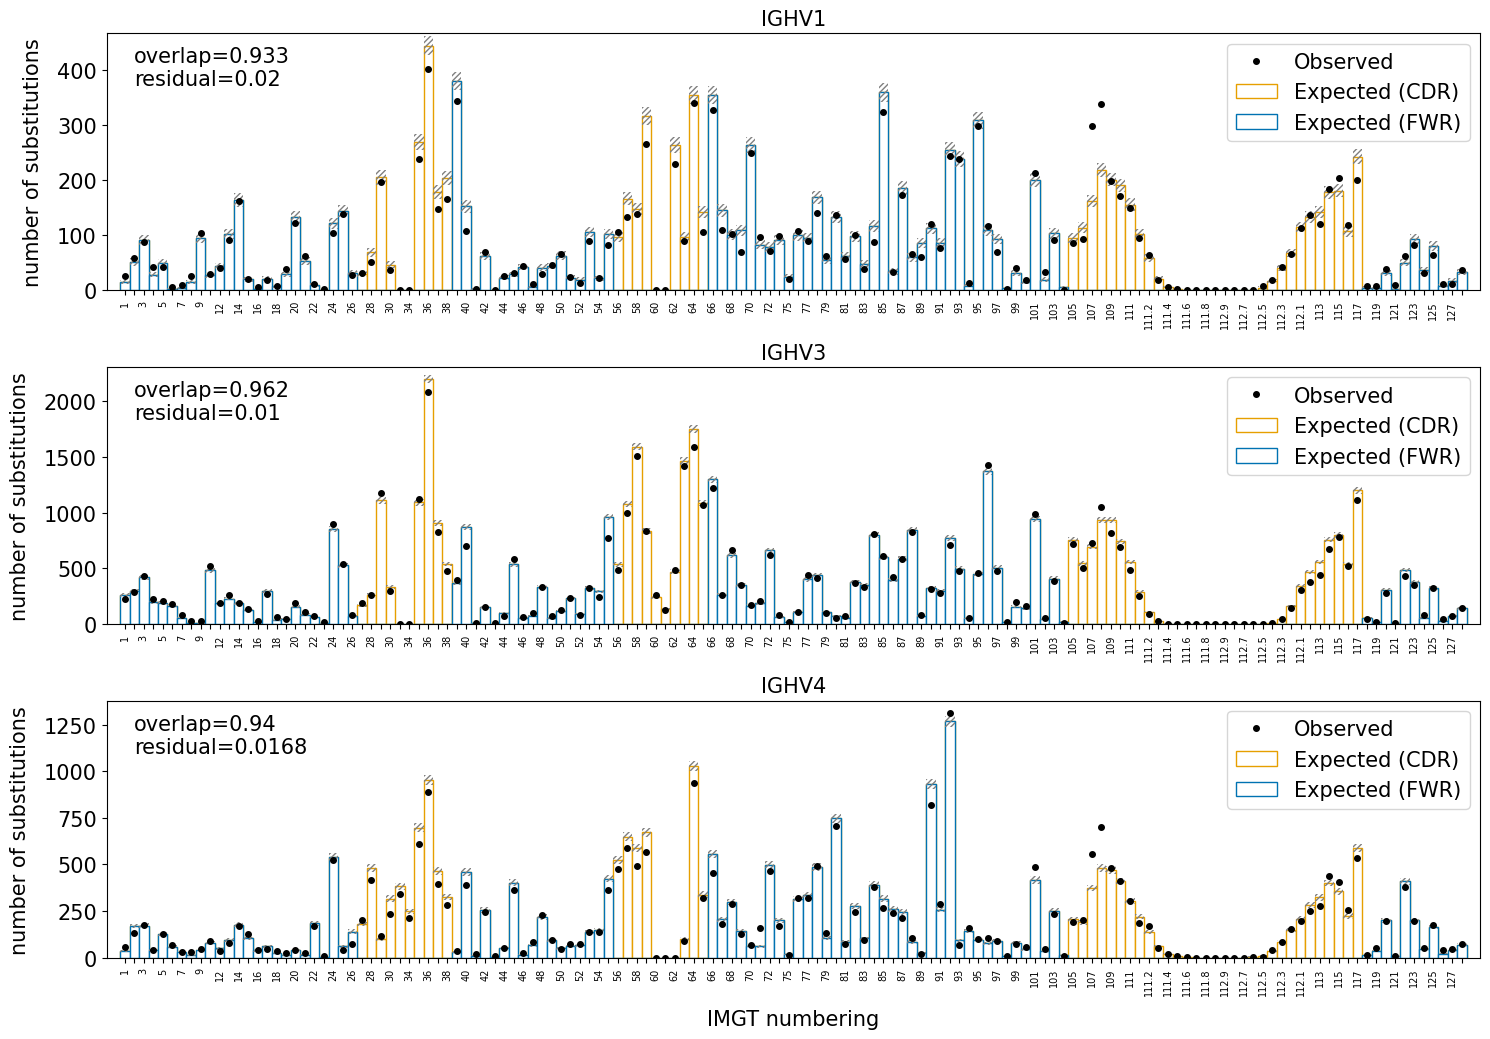

In [ ]:
dataset_name = "v1vanwinkleheavyTestnoN"
model_name = "dnsm_1m-v1jaffe+v1tang-joint"

crepe_prefix = localify(f"DNSM_TRAINED_MODELS_DIR/{model_name}")
test_output_prefix = localify(f"DNSM_TEST_OUTPUT_DIR/{model_name}-ON-{dataset_name}")

if not os.path.exists(f"{test_output_prefix}.branch_lengths_csv"):
    dnsm_zoo.write_branch_lengths("/fh/fast/matsen_e/shared/bcr-mut-sel/dnsm/dnsm-experiments-1/dnsm-train/trained_models/dnsm_1m-v1jaffe+v1tang-joint", "v1vanwinkleheavyTestnoN", f"{test_output_prefix}.branch_lengths_csv")

    # when trying to run this, I got an error about not being in the anarci dict. so I added the same entry as the 
    #     "v1vanwinkleheavyTestnoN": "DATA_DIR/anarci/vanwinkle-170-igh_anarci-seqs_imgt_H_patch.csv", is this okay??
complete_plotter, plotter_dict = write_sites_oe(
    crepe_prefix=crepe_prefix,
    dataset_name=dataset_name,
    #branch_length_path=f"/fh/fast/matsen_e/wdumm/for_noam/dnsm_1m-v1jaffe+v1tang-joint_ON_v1vanwinkleheavyTest_branch_lengths_csv",
    branch_length_path=f"{test_output_prefix}.branch_lengths_csv",
    csv_output_path=f"{test_output_prefix}-sites-oe.csv",
    v_families=["IGHV1", "IGHV2", "IGHV3", "IGHV4", "IGHV5", "IGHV6", "IGHV7"],
    fig_out_path=f"{figures_dir}/sites-oe-V1,3,4.svg",
    min_log_prob=-4,
    replace_title=True,
)
complete_plotter = complete_plotter["h"]

### Comparing selection factors and mutation frequencies between V3 and V4

In [ ]:

def site_sub_probs_df_without_low_freq(in_plotter, quantile_cutoff=0.05):
    site_sub_probs_df = in_plotter.site_sub_probs_df.copy()
    site_counts = site_sub_probs_df["site"].value_counts()
    cutoff = site_counts.quantile(quantile_cutoff)
    sites_above_cutoff = set(site_counts[site_counts > cutoff].index)
    site_sub_probs_df = site_sub_probs_df[site_sub_probs_df["site"].isin(sites_above_cutoff)]
    return site_sub_probs_df

def sort_df_by_site(df):
    sorted_index = natsorted(df.index, key=lambda x: df.loc[x, 'site'])
    return df.iloc[sorted_index]

def build_persite_df(site_sub_probs_df):
    persite_df = site_sub_probs_df.groupby(['site', 'is_cdr']).agg(
        mean_prob=('prob', 'mean'),
        mean_neutral_prob=('neutral_prob', 'mean'),
        mean_selection_factor=('selection_factor', 'mean'),
        mut_freq=('mutation', 'mean')
    ).reset_index()

    persite_df = sort_df_by_site(persite_df)

    return persite_df


# Assign plotters for all seven IGHV families
plotterV1 = plotter_dict["IGHV1h"]
plotterV2 = plotter_dict["IGHV2h"]
plotterV3 = plotter_dict["IGHV3h"]
plotterV4 = plotter_dict["IGHV4h"]
plotterV5 = plotter_dict["IGHV5h"]
plotterV6 = plotter_dict["IGHV6h"]
plotterV7 = plotter_dict["IGHV7h"]

# First, build persite dataframes for all seven IGHV families
# this can be used to get sites in common that are present in at least 0.05 of each family
persiteV1 = build_persite_df(site_sub_probs_df_without_low_freq(plotterV1))
persiteV2 = build_persite_df(site_sub_probs_df_without_low_freq(plotterV2))
persiteV3 = build_persite_df(site_sub_probs_df_without_low_freq(plotterV3))
persiteV4 = build_persite_df(site_sub_probs_df_without_low_freq(plotterV4))
persiteV5 = build_persite_df(site_sub_probs_df_without_low_freq(plotterV5))
persiteV6 = build_persite_df(site_sub_probs_df_without_low_freq(plotterV6))
persiteV7 = build_persite_df(site_sub_probs_df_without_low_freq(plotterV7))

# Create a list of all persite dataframes that are not None
persite_dfs = []
for i in range(1, 8):
    var_name = f"persiteV{i}"
    if globals()[var_name] is not None and len(globals()[var_name]) > 0:
        persite_dfs.append(globals()[var_name])

# Find common sites across all non-empty dataframes
if persite_dfs:
    common_sites = set(persite_dfs[0]["site"])
    for df in persite_dfs[1:]:
        common_sites &= set(df["site"])
    
    print(f"Found {len(common_sites)} common sites across available V families")
else:
    common_sites = set()
    print("No valid persite dataframes found")

# Restrict each persite dataframe to common sites
for i in range(1, 8):
    var_name = f"persiteV{i}"
    var_name_common = f"persiteV{i}_common"
    
    if globals()[var_name] is not None and len(globals()[var_name]) > 0:
        globals()[var_name_common] = globals()[var_name][globals()[var_name]["site"].isin(common_sites)]
        print(f"{var_name_common}: {len(globals()[var_name_common])} rows")
    else:
        globals()[var_name_common] = None
        print(f"{var_name_common} is None (source dataframe was empty)")



for plotter in plotter_dict.values():
    for colname in ["neutral_prob", "selection_factor", "prob"]:
        plotter.site_sub_probs_df[colname] = plotter.site_sub_probs_df[colname].apply(lambda it: it.item())
for colname in ["neutral_prob", "selection_factor", "prob"]:
    complete_plotter.site_sub_probs_df[colname] = complete_plotter.site_sub_probs_df[colname].apply(lambda it: it.item())


    complete_plotter.mut_obs_pred_df


In [ ]:
# add j gene data
vanwinkle_j_df = load_pcp_df('/fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v1/vanwinkle-170-igh_pcp_2025-03-05_MASKED_NI_no-naive_addJ.csv.gz')
complete_plotter.pcp_df = pd.merge(complete_plotter.pcp_df, vanwinkle_j_df.rename(columns={'parent_h':'parent', 'child_h':'child'})[['parent', 'child', 'j_gene', 'v_gene_h']], on=['orig_pcp_idx', 'parent', 'child'], how='left')
